# DARTS

## Introducción

Biblioteca específica de Python para series de tiempo. Su objetivo es simplificar todo el proceso de modelado, pronóstico y análisis de datos temporales.


Proporciona una interfaz para usar diferentes tipos de modelos:

- Modelos estadísticos clásicos (ARIMA, exponential smoothing)

- Modelos de machine learning (Random Forest, LightGBM)

- Modelos de deep learning (LSTM, Transformer, N-BEATS)

## Librerias

In [2]:
! pip install darts

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.9/62.9 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 2.6 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of numba to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 744.5/744.5 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.7/204.7 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 58.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 74.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.9 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: llvmlite
    Found existing installation: llvmlit

In [1]:
import darts

In [2]:
# Se cargan las librerías
from pandas import DataFrame
from pandas import concat
import random
from scipy import stats
import numpy as np
import pandas as pd
from math import sqrt
from numpy import concatenate
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from darts.metrics import mape, rmse, mae
from pandas import DataFrame
from pandas import concat
import seaborn as sn
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import gc
#from darts.ad import QuantileDetector
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [3]:
pip install pytorch-lightning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 22.9 MB/s eta 0:00:00


In [4]:
from darts import TimeSeries
from darts.models import (NaiveSeasonal,NaiveDrift,RNNModel,Prophet,ExponentialSmoothing,ARIMA,AutoARIMA,TCNModel,TransformerModel,Theta,FFT)

## Paso 1: Preparar los datos

Preparar los datos es un paso importante en series de tiempo porque los modelos necesitan entender la estructura temporal de los datos. Un índice datetime correcto permite que el modelo identifique patrones estacionales y tendencias. Los datos mal preparados generan modelos que no detectan patrones reales, mientras que datos limpios permiten predicciones confiables que pueden identificar correctamente picos de cortes de luz y tendencias temporales.

**Variable objetivo:** Búsquedas de Google Trends (proxy de cortes de luz)
**Variables exógenas**: Temp (temperatura), Hum (humedad)
**Índice temporal:** Semana (datos semanales)

In [5]:
df = pd.read_csv("completo.csv")
df['Semana'] = pd.to_datetime(df['Semana'])
df.set_index('Semana', inplace=True)

In [6]:
df['Temp'] = df['Temp'].astype(str).str.replace(',', '.').astype(float)
df['Hum'] = df['Hum'].astype(str).str.replace(',', '.').astype(float)

print(df.head())

            Cortes       Temp        Hum
Semana                                  
2020-12-06      17  20.735714  62.532857
2020-12-13      23  24.490000  49.370000
2020-12-20      22  23.690000  51.560000
2020-12-27      37  27.928571  48.910000
2021-01-03      27  27.341429  39.745714


## Paso 2: evaluación exploratoria (esto ya se hizo en el TP1)

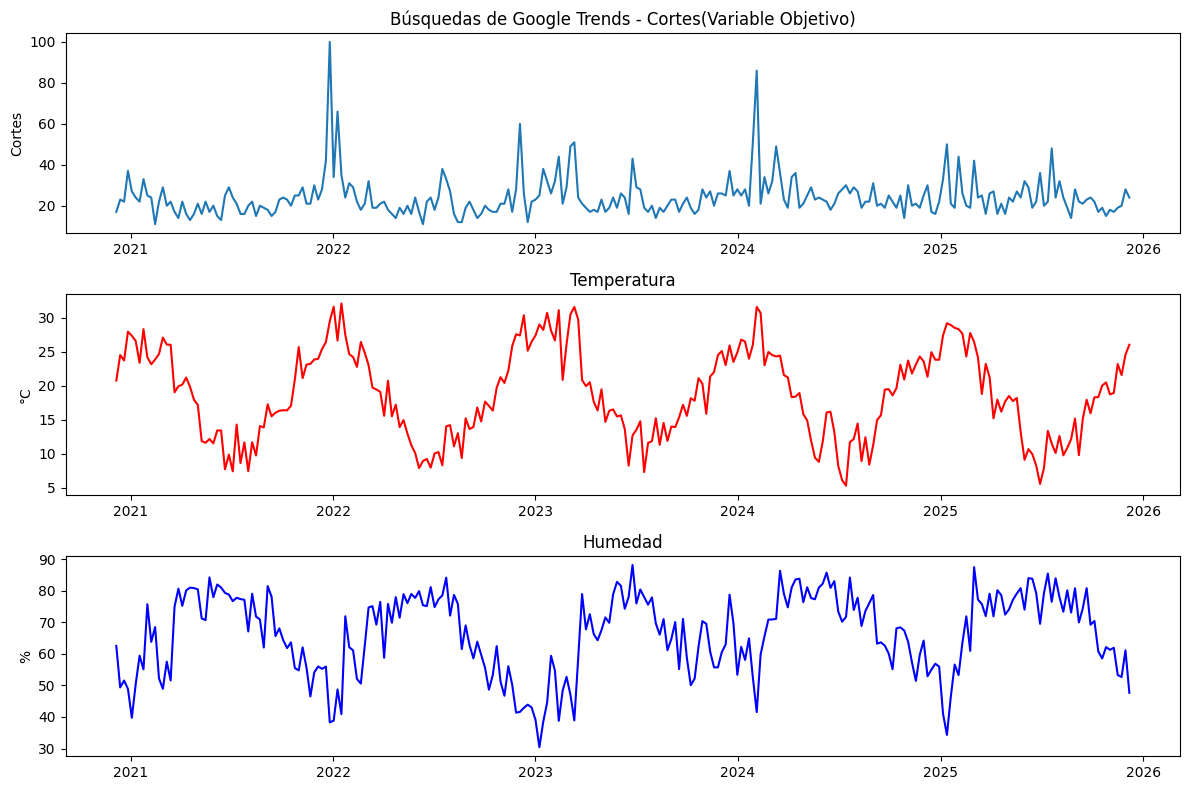

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8))

axes[0].plot(df.index, df['Cortes'])
axes[0].set_title('Búsquedas de Google Trends - Cortes(Variable Objetivo)')
axes[0].set_ylabel('Cortes')

axes[1].plot(df.index, df['Temp'], color='red')
axes[1].set_title('Temperatura')
axes[1].set_ylabel('°C')

axes[2].plot(df.index, df['Hum'], color='blue')
axes[2].set_title('Humedad')
axes[2].set_ylabel('%')

plt.tight_layout()
plt.show()



In [9]:
print(df.describe())

           Cortes        Temp         Hum
count  262.000000  262.000000  262.000000
mean    24.251908   18.687339   66.438353
std     10.101283    6.465557   12.642814
min     11.000000    5.277143   30.422857
25%     19.000000   13.666786   56.693214
50%     22.000000   18.430714   69.264286
75%     26.750000   24.090357   77.375714
max    100.000000   32.082857   88.212857


In [10]:
serie_cortes = TimeSeries.from_dataframe(
    df[['Cortes']],
    time_col=None,
    value_cols='Cortes',
    freq='W'  # W frecuencia es semanal
)

In [11]:
serie_temp = TimeSeries.from_dataframe(
    df[['Temp']],
    value_cols='Temp',
    freq='W'
)


In [12]:
serie_hum = TimeSeries.from_dataframe(
    df[['Hum']],
    value_cols='Hum',
    freq='W'
)

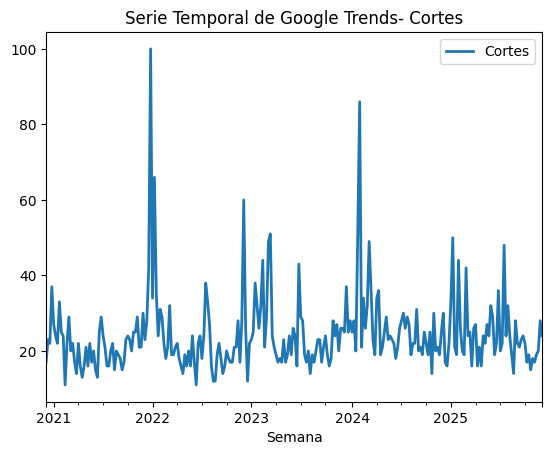

In [13]:
serie_cortes.plot(label='Cortes')
plt.title('Serie Temporal de Google Trends- Cortes')
plt.show()

## Paso 3: dividir datos en entrenamiento y prueba

En series de tiempo, la división de datos difiere fundamentalmente del machine learning tradicional porque debe respetar el orden cronológico de las observaciones: el conjunto de entrenamiento (*training*) siempre representa el pasado y los datos de prueba (*testing*) el futuro que queremos predecir.


Utilizamos una división 80/20 donde las primeras 80% observaciones entrenan al modelo y las últimas 20% evalúan su capacidad predictiva. Esta proporción asume que tenemos los suficientes datos históricos.

Un embargo temporal (gap entre training/testing) puede agregarse si hay autocorrelación muy fuerte o delays en los reportes, pero al predecir un par de semanas adelante este gap suele ser innecesario ya que la distancia del forecast horizon actúa como buffer natural.

In [14]:
# Dividir en 80% entrenamiento, 20% test
split_point = int(0.8 * len(serie_cortes))

train = serie_cortes[:split_point]
test = serie_cortes[split_point:]

# Lo mismo para covariables
train_temp = serie_temp[:split_point]
test_temp = serie_temp[split_point:]

train_hum = serie_hum[:split_point]
test_hum = serie_hum[split_point:]


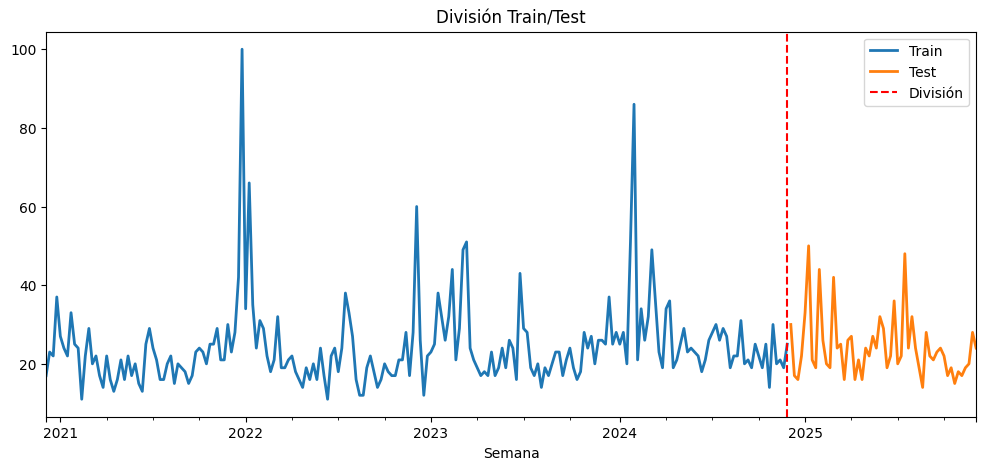

In [15]:
plt.figure(figsize=(12, 5))
train.plot(label='Train')
test.plot(label='Test')
plt.axvline(x=train.end_time(), color='red', linestyle='--', label='División')
plt.legend()
plt.title('División Train/Test')
plt.show()

## Paso 4: Modelo Baseline - Exponential Smoothing


El modelo **Exponential Smoothing**, pondera más las observaciones recientes y menos las lejanas para capturar tendencias. Sirve como punto de referencia o *benchmark*, cualquier modelo más complejo debe superar este modelo para justificar su uso.

Evaluamos el desempeño utiliando 3 métricas:

- **MAPE** : Error porcentual promedio ("me equivoco x% en promedio").

- **MAE**: Error absoluto robusto a outliers.

- **RMSE**: Root Mean Square Error (pensaliza errores grandes, nos ayuda a ver si fallamos mucho cuando la serie se dispara).

In [16]:
modelo_exp = ExponentialSmoothing()
modelo_exp.fit(train)

ExponentialSmoothing(trend=ModelMode.ADDITIVE, damped=False, seasonal=SeasonalityMode.ADDITIVE, seasonal_periods=None, error=add, random_errors=None, random_state=None, kwargs=None)

In [17]:
pred_exp = modelo_exp.predict(n=len(test))

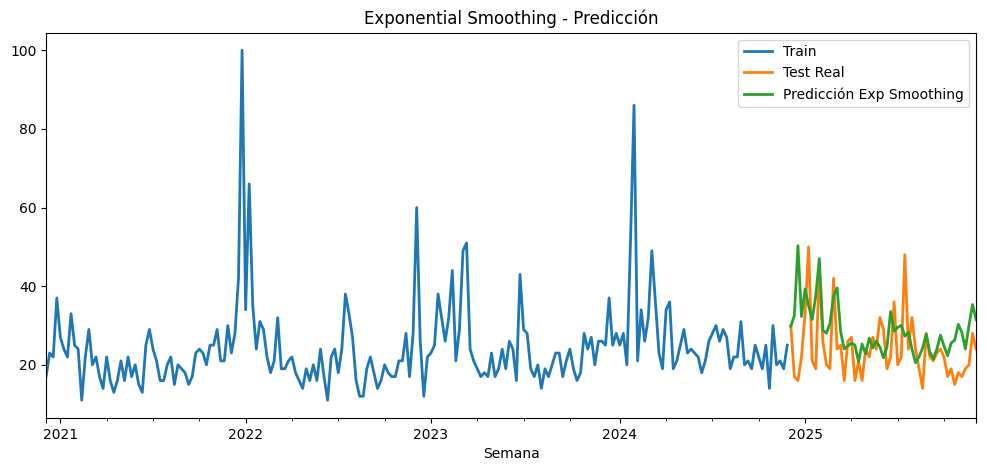

In [18]:
plt.figure(figsize=(12, 5))
train.plot(label='Train')
test.plot(label='Test Real')
pred_exp.plot(label='Predicción Exp Smoothing')
plt.legend()
plt.title('Exponential Smoothing - Predicción')
plt.show()

In [19]:
mape_exp = mape(test, pred_exp)
rmse_exp = rmse(test, pred_exp)
mae_exp = mae(test, pred_exp)

print(f"MAPE: {mape(test, pred_exp):.2f}%")
print(f"RMSE: {rmse(test, pred_exp):.2f}")
print(f"MAE: {mae(test, pred_exp):.2f}")

MAPE: 34.98%
RMSE: 9.57
MAE: 7.40


El modelo baseline muestra un **MAPE de 34.98%**, lo que indica un error porcentual moderado-alto. Esto significa que en promedio nos equivocamos aproximadamente 35% en nuestras predicciones de casos de cortes de luz.

El **MAE de 7.40 casos** nos dice que en promedio erramos por ±7-8 casos.

El **RMSE de 9.58** es mayor que el MAE (7.40), lo cual es esperado porque RMSE penaliza más los errores grandes. La diferencia moderada entre ambos (9.58 vs 7.40) sugiere que el modelo tiene algunos errores grandes pero no extremos, probablemente en semanas con picos de búsqueda de cortes de luz que no anticipó bien.

**Conclusión:** Este baseline establece que necesitamos modelos más sofisticados (ARIMA, Prophet con covariables climáticas) para mejorar el MAPE por debajo del 25%. La volatilidad de los casos de cortes posiblemente la influencia de temperatura/humedad requieren enfoques que capturen mejor la estacionalidad y relaciones causales.

## Paso 5: Modelo ARIMA

El moelo **ARIMA** (*AutoRegressive Integrated Moving Average*) es un modelo clásico de series de tiempo que combina tres componentes: un componente autoregresivo (AR - que utiliza valores pasados), el componente de integración I (diferenciación para estacionariedad) y finalmente la componente media móvil (usa errores pasados).

En el Trabajo Práctico 1 trabajamos con este modelo y realizamos una selección mediante un grid search, utilizando criterios como AIC/BIC y análasis de autocorrelación (ACF/PACF).
Darts simplifica este proceso usando AutoARIMA, que automáticamente busca la mejor combinación de parámetros.

In [20]:
modelo_arima = ARIMA()
modelo_arima.fit(train)

pred_arima = modelo_arima.predict(n=len(test))

In [21]:
modelo_arima

ARIMA(p=12, d=1, q=0, seasonal_order=(0, 0, 0, 0), trend=None, random_state=None, add_encoders=None)

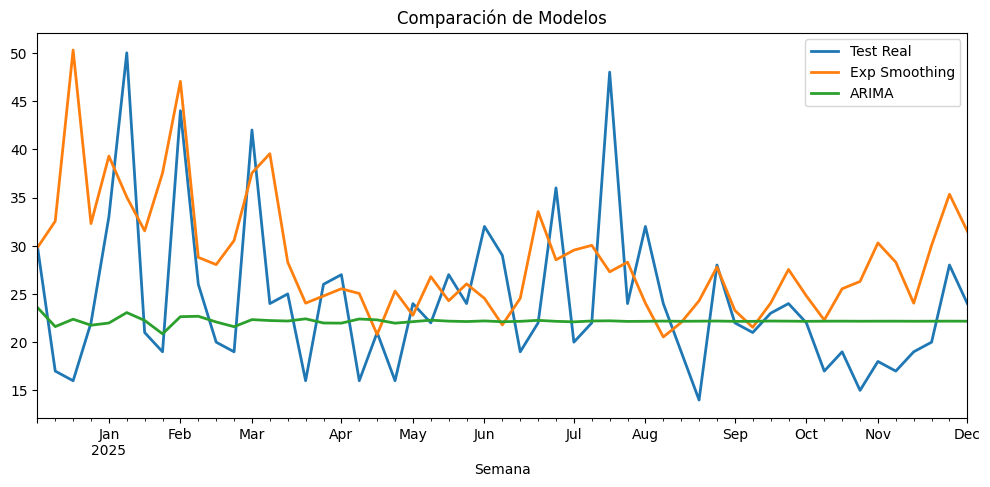

In [22]:
plt.figure(figsize=(12, 5))
test.plot(label='Test Real')
pred_exp.plot(label='Exp Smoothing')
pred_arima.plot(label='ARIMA')
plt.legend()
plt.title('Comparación de Modelos')
plt.show()


Este gráfico nos muestra una falla del modelo ARIMA, prácticamente predice una línea horizontal en varias semanas, siendo completamente insensible a la variabilidad real de los datos. Mientras que los datos del testing (línea azul) muestran volatilidad, con picos y valles, vemos que el Exponential Smoothing (línea naranja) intenta seguir las fluctuaciones aunque con un poco de delay, la línea verde del modelo ARIMA produce una línea casi recta que ignora patrones temporales.

Este comportamiento ocurre típicamente cuando ARIMA sobrediferencia la serie o cuando los parámetros llevan a una predicción que converge rápidamente a la media. En este caso el modelo ARIMA(12,1,0) con d=1 probablemente eliminó demasiada información al diferencias una serie que ya era estacionaria (comprobado en el TP 1), convergiendo a la media debido a que los 12 lags autoregresivos sin componente MA se promedian hacia un valor constante. También carece de un componente estacional explícito, por lo que no puede capturar ciclos anuales característicos de los cortes de luz.

In [23]:
mape_arima = mape(test, pred_arima)
rmse_arima= rmse(test, pred_arima)
mae_arima= mae(test, pred_arima)

print("ARIMA:")
print(f"MAPE: {mape(test, pred_arima):.2f}%")
print(f"RMSE: {rmse(test, pred_arima):.2f}")

ARIMA:
MAPE: 20.30%
RMSE: 8.06


Obtenemos un MAPE de 20.3%, que no necesariamente indica que ARIMA prediga mejor que el Exponential Smoothing, sino que la serie de datos observados tiene una media cercana a 22, y predecir constantemente este valor genera un error "aceptable". Es mejor que el modelo bechmark numéricamente, solo porque no intenta seguir los cambios, y paradójicamente, falla menos dramáticamente al arriesgare menos. El número sugiere mejora, pero visualmente el modelo es completamente inútil para decisiones operativas.

Estos resultados evidencian que necesitamos enfoques diferentes. **En el Paso X** probaremos modelos alternativos diseñados específicamente para capturar estacionalidad y patrones complejos-

*Nota: En el TP1, utilizamos AUTOARIMA de pmdarima (librería statsmodels) y obtuvimos el modelo ARIMA(1,0,1)x(0,0,0)[52].  La discrepancia entre modelos se debe a que utilizando diferentes estrategias de búsqueda, pmdarima utiliza stepwise search, mientras que dart utilizao un grid search más amplio. También pmdarima puede limitar los parámetros, mientras que Darts perimite rangos mayores. También pmdarima penaliza más fuertemente la complejidad de los modelos.*

## Paso 6: Redes Neuronales

Tras explorar modelos estadísticos clásicos como Exponential Smoothing y ARIMA, avanzamos hacia técnicas de *deep learning* que prometen capturar patrones no lineales y relaciones complejas en series temporales. Las **redes neuronales recurrentes (RNN)**, específicamente la arquitectura **LSTM (Long Short-Term Memory)**, representan un enfoque fundamentalmente diferente: en lugar de modelar explícitamente componentes como tendencia, estacionalidad o autocorrelación mediante ecuaciones matemáticas (como ARIMA), las LSTM aprenden representaciones latentes de la serie a través de múltiples capas de neuronas que procesan secuencias temporales, identificando automáticamente dependencias de corto y largo plazo sin requerir especificación manual de parámetros p, d, q.

La arquitectura LSTM aborda una limitación crítica de las RNN tradicionales: el **problema del gradiente desvaneciente** que dificulta el aprendizaje de dependencias temporales lejanas. LSTM incorpora mecanismos de compuertas (forget gate, input gate, output gate) que controlan selectivamente qué información del pasado debe retenerse, actualizarse u olvidarse, permitiendo que la red "recuerde" patrones relevantes ocurridos muchas semanas atrás mientras descarta ruido. Para nuestro problema de búsquedas de cortes de luz en Google Trends, esto significa que el modelo puede aprender, por ejemplo, que un aumento gradual de búsquedas durante 8-10 semanas frecuentemente precede un pico extremo, o que ciertos patrones estacionales de hace 52 semanas (un año atrás) son predictivos del comportamiento actual, relaciones que modelos más simples no capturan eficientemente.

Configuramos el modelo LSTM con hiperparámetros balanceados entre capacidad de aprendizaje y riesgo de sobreajuste: *input_chunk_length=12* significa que la red procesa ventanas de 12 semanas anteriores para predecir valores futuros, capturando patrones trimestrales; *3 capas LSTM con 32 neuronas ocultas* por capa proporcionan profundidad suficiente para aprender representaciones complejas sin volverse excesivamente parametrizado dado nuestro dataset de ~150 observaciones; *dropout=0.1* introduce regularización que aleatoriamente desactiva 10% de las neuronas durante entrenamiento, previniendo que el modelo memorice ruido específico del conjunto de entrenamiento; y *100 epochs con learning rate 0.01* permiten convergencia gradual mediante descenso de gradiente. Crítico para LSTM es la *normalización de datos* (usando Scaler para transformar valores a rango 0-1), ya que las redes neuronales son sensibles a la escala de entrada y convergen más eficientemente con datos estandarizados, un requisito que no existía para Exponential Smoothing o ARIMA que operan directamente sobre valores originales.

In [24]:
from darts.models import RNNModel
from darts.dataprocessing.transformers import Scaler
import numpy as np

In [25]:
scaler = Scaler()
train_scaled = scaler.fit_transform(train)
test_scaled = scaler.transform(test)
serie_scaled = scaler.transform(serie_cortes)

In [26]:
modelo_lstm = RNNModel(
    model='LSTM',
    input_chunk_length=12,      # Usar batches de 12 semanas
    hidden_dim=32,               # Neuronas ocultas
    n_rnn_layers=3,             # 3 capas LSTM
    dropout=0.1,                # Regularización
    batch_size=32,
    n_epochs=100,               # Iteraciones de entrenamiento
    optimizer_kwargs={'lr': 1e-2},
    pl_trainer_kwargs={
        "accelerator": "cpu",
        "enable_progress_bar": True
    },
    random_state=42
)

In [27]:
modelo_lstm.fit(train_scaled.astype(np.float32))

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ criterion       │ MSELoss          │      0 │ train │     0 │
│ 1 │ train_criterion │ MSELoss          │      0 │ train │     0 │
│ 2 │ val_criterion   │ MSELoss          │      0 │ train │     0 │
│ 3 │ train_metrics   │ MetricCollection │      0 │ train │     0 │
│ 4 │ val_metrics     │ MetricCollection │      0 │ train │     0 │
│ 5 │ rnn             │ LSTM             │ 21.4 K │ train │     0 │
│ 6 │ V               │ Linear           │     33 │ train │     0 │
└───┴─────────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 21.4 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 21.4 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 7                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.


RNNModel(model=LSTM, hidden_dim=32, n_rnn_layers=3, dropout=0.1, training_length=24, input_chunk_length=12, batch_size=32, n_epochs=100, optimizer_kwargs={'lr': 0.01}, pl_trainer_kwargs={'accelerator': 'cpu', 'enable_progress_bar': True}, random_state=42)

In [28]:
pred_lstm_scaled = modelo_lstm.predict(n=len(test))

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

In [29]:
pred_lstm = scaler.inverse_transform(pred_lstm_scaled)

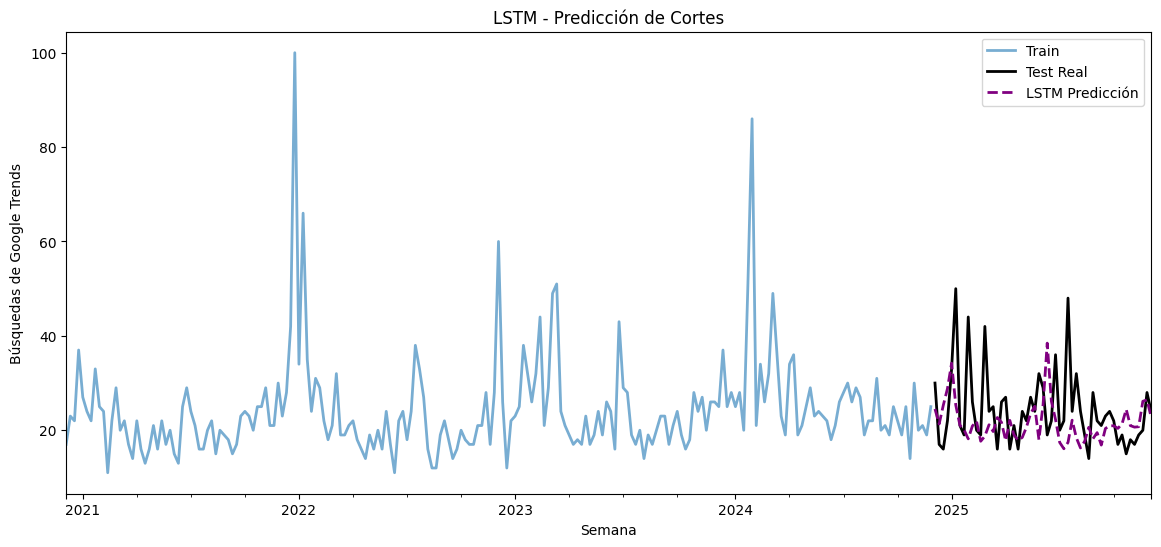

In [30]:
plt.figure(figsize=(14, 6))
train.plot(label='Train', alpha=0.6)
test.plot(label='Test Real', linewidth=2, color='black')
pred_lstm.plot(label='LSTM Predicción', linestyle='--', color='purple')
plt.legend()
plt.title('LSTM - Predicción de Cortes')
plt.ylabel('Búsquedas de Google Trends')
plt.show()

In [31]:
mape_lstm = mape(test, pred_lstm)
rmse_lstm = rmse(test, pred_lstm)
mae_lstm = mae(test, pred_lstm)

print(f"\nMétricas LSTM:")
print(f"  MAPE: {mape_lstm:.2f}%")
print(f"  RMSE: {rmse_lstm:.2f}")
print(f"  MAE:  {mae_lstm:.2f}")


Métricas LSTM:
  MAPE: 24.67%
  RMSE: 9.40
  MAE:  6.43


La predicción LSTM no es una línea plana ni oscilaciones artificiales regulares, sino que intenta rastrear los movimientos reales de la serie.



## Paso 7: FFT (Fast Fourier Transform)

Tras evaluar modelos estadísticos clásicos (Exponential Smoothing, ARIMA) y redes neuronales profundas (LSTM), exploramos un enfoque radicalmente diferente basado en análisis espectral: la **Transformada Rápida de Fourier (FFT)**. A diferencia de los modelos anteriores que trabajan en el dominio temporal (prediciendo valores futuros basándose en valores pasados secuenciales), FFT opera en el dominio de frecuencias, descomponiendo la serie temporal en una suma de ondas sinusoidales de diferentes frecuencias que, al combinarse, reconstruyen el patrón observado. Este enfoque es particularmente poderoso cuando la serie exhibe periodicidades claras y regulares: si las búsquedas de cortes de luz siguen ciclos predecibles (estacionalidad anual relacionada con clima, patrones mensuales de consumo eléctrico, o fluctuaciones semanales de actividad), FFT identifica estas frecuencias dominantes y las utiliza para proyectar el comportamiento futuro.

El algoritmo FFT transforma la serie de tiempo desde su representación original (valores de búsquedas semana a semana) a una representación espectral que muestra la intensidad de cada frecuencia presente en los datos.  El parámetro *nr_freqs_to_keep=10* retiene solo las 10 frecuencias más importantes (aquellas con mayor amplitud), filtrando ruido de alta frecuencia que no aporta poder predictivo y podría causar sobreajuste. Esta selección automática de componentes relevantes es análoga a reducción de dimensionalidad: en lugar de modelar cada fluctuación aleatoria, FFT captura solo los ciclos estructurales que genuinamente explican la dinámica de la serie.

Adicionalmente, incorporamos *modelado de tendencia polinomial* (trend='poly', degree=2) que captura movimientos de largo plazo no cíclicos antes de aplicar la descomposición de frecuencias. Esto es crucial porque FFT asume que la serie es estacionaria (sin tendencia global). El polinomio de grado 2 permite modelar tendencias curvadas (parabólicas): si las búsquedas han estado aumentando aceleradamente, el componente polinomial lo captura, mientras que FFT modela las oscilaciones alrededor de esa tendencia.

In [32]:
modelo_fft = FFT(
    nr_freqs_to_keep=10,  # Top 10 frecuencias principales
    trend='poly',          # Incluir tendencia polinomial
    trend_poly_degree=2    # Grado 2
)
modelo_fft.fit(train)

FFT(nr_freqs_to_keep=10, required_matches=None, trend=poly, trend_poly_degree=2)

In [33]:
pred_fft = modelo_fft.predict(n=len(test))


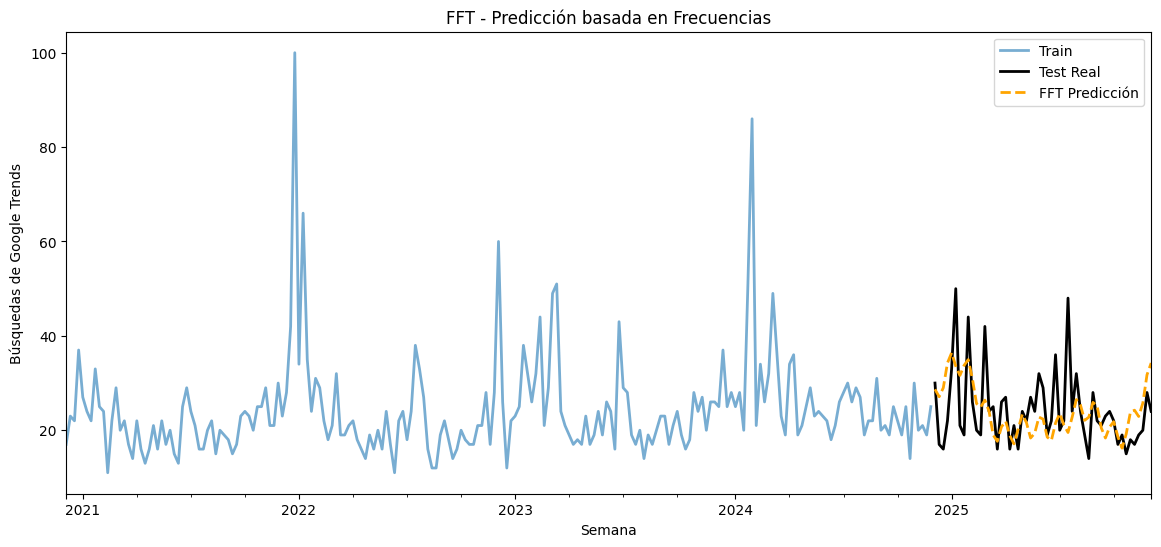

In [34]:
plt.figure(figsize=(14, 6))
train.plot(label='Train', alpha=0.6)
test.plot(label='Test Real', linewidth=2, color='black')
pred_fft.plot(label='FFT Predicción', linestyle='--', color='orange')
plt.legend()
plt.title('FFT - Predicción basada en Frecuencias')
plt.ylabel('Búsquedas de Google Trends')
plt.show()

In [35]:
# Métricas
mape_fft = mape(test, pred_fft)
rmse_fft = rmse(test, pred_fft)
mae_fft = mae(test, pred_fft)

print(f"\nMétricas FFT:")
print(f"  MAPE: {mape_fft:.2f}%")
print(f"  RMSE: {rmse_fft:.2f}")
print(f"  MAE:  {mae_fft:.2f}")


Métricas FFT:
  MAPE: 24.39%
  RMSE: 7.90
  MAE:  5.91


El gráfico de predicción del modelo FFT muestra un comportamiento intermedio que revela tanto fortalezas como limitaciones críticas del análisis espectral para este problema. La predicción captura el nivel general de actividad y algunos movimientos ascendentes/descendentes, pero parecería fallar sistemáticamente en magnitud y timing de los picos.

## Paso 8: Transformers

Habiendo explorado LSTM que procesa secuencias temporales de forma recurrente (paso a paso, manteniendo memoria mediante compuertas), avanzamos hacia la arquitectura más revolucionaria en deep learning de la última década: **Transformers**. Originalmente desarrollados para procesamiento de lenguaje natural (GPT, BERT), los Transformers han demostrado capacidad excepcional en series temporales al introducir el *mecanismo de atención*, que permite al modelo identificar qué partes del pasado son más relevantes para predecir el futuro sin procesar secuencialmente cada timestep. A diferencia de LSTM que "lee" la serie de izquierda a derecha actualizando su estado interno gradualmente, Transformer observa simultáneamente todos los puntos temporales y aprende pesos de atención que cuantifican la importancia relativa de cada semana histórica para la predicción actual, capturando dependencias tanto locales (últimas 2-3 semanas) como globales (patrones de hace 30+ semanas) de forma más eficiente.


Los hiperparámetros balancean expresividad y eficiencia computacional: *d_model=64* define la dimensionalidad de las representaciones internas (menor que modelos de lenguaje natural que usan 512-1024, ajustado a nuestro dataset más pequeño); *dim_feedforward=128* controla la capacidad de las capas densas dentro de cada bloque Transformer; *dropout=0.1* regulariza para prevenir sobreajuste; y *learning rate=1e-3* (menor que LSTM's 1e-2) reconoce que Transformers requieren optimización más cautelosa. Crítico destacar que Transformer *no tiene sesgo inductivo temporal* como LSTM (que asume que el pasado reciente es más importante): aprende completamente desde datos qué patrones temporales importan, lo cual es poderoso si hay suficientes datos pero arriesgado con datasets pequeños (~150 observaciones).

In [36]:
from darts.models import TransformerModel

# Crear Transformer
modelo_transformer = TransformerModel(
    input_chunk_length=12,        # Input: 12 semanas
    output_chunk_length=4,        # Output: predecir 4 semanas
    d_model=64,                   # Dimensión del modelo
    nhead=4,                      # Cabezas de atención
    num_encoder_layers=2,         # Capas del encoder
    num_decoder_layers=2,         # Capas del decoder
    dim_feedforward=128,
    dropout=0.1,
    batch_size=32,
    n_epochs=100,
    optimizer_kwargs={'lr': 1e-3},
    pl_trainer_kwargs={
        "accelerator": "auto",
        "enable_progress_bar": True
    },
    random_state=42
)

In [37]:
modelo_transformer.fit(train_scaled.astype(np.float32))


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                ┃ Type                ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ criterion           │ MSELoss             │      0 │ train │     0 │
│ 1 │ train_criterion     │ MSELoss             │      0 │ train │     0 │
│ 2 │ val_criterion       │ MSELoss             │      0 │ train │     0 │
│ 3 │ train_metrics       │ MetricCollection    │      0 │ train │     0 │
│ 4 │ val_metrics         │ MetricCollection    │      0 │ train │     0 │
│ 5 │ encoder             │ Linear              │    128 │ train │     0 │
│ 6 │ positional_encoding │ _PositionalEncoding │      0 │ train │     0 │
│ 7 │ transformer         │ Transformer         │  167 K │ train │     0 │
│ 8 │ decoder             │ Linear              │    260 │ train │     0 │
└───┴─────────────────────┴─────────────────────┴────────┴───────┴───────┘

Trainable params: 168 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 168 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 64                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.


TransformerModel(output_chunk_shift=0, d_model=64, nhead=4, num_encoder_layers=2, num_decoder_layers=2, dim_feedforward=128, dropout=0.1, activation=relu, norm_type=None, custom_encoder=None, custom_decoder=None, input_chunk_length=12, output_chunk_length=4, batch_size=32, n_epochs=100, optimizer_kwargs={'lr': 0.001}, pl_trainer_kwargs={'accelerator': 'auto', 'enable_progress_bar': True}, random_state=42)

In [38]:
pred_transformer_scaled = modelo_transformer.predict(n=len(test))
pred_transformer = scaler.inverse_transform(pred_transformer_scaled)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

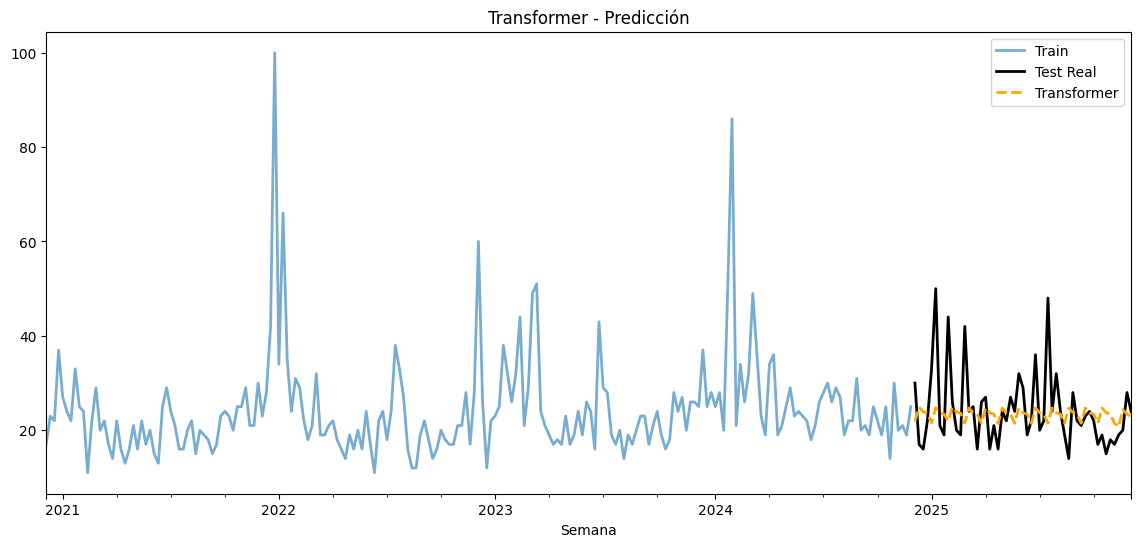

In [39]:
plt.figure(figsize=(14, 6))
train.plot(label='Train', alpha=0.6)
test.plot(label='Test Real', linewidth=2, color='black')
pred_transformer.plot(label='Transformer', linestyle='--', color='orange')
plt.legend()
plt.title('Transformer - Predicción')
plt.show()

In [40]:
mape_transformer = mape(test, pred_transformer)
rmse_transformer = rmse(test, pred_transformer)
mae_transformer = mae(test, pred_transformer)

El gráfico de predicción del modelo Transformer revela el problema fundamental que anticipamos en el análisis teórico: a pesar de su arquitectura sofisticada con mecanismos de atención, el modelo produce una *línea prácticamente horizontal* alrededor de 22-25 búsquedas que ignora completamente la volatilidad real de la serie.


## Paso 9: comparación de modelos

Habiendo entrenado cinco modelos con filosofías  diferentes desde el simple pero efectivo **Exponential Smoothing** hasta arquitecturas de deep learning como **LSTM y Transformer**, pasando por el clásico **ARIMA** y el análisis espectral de **FFT**—procedemos a una evaluación sistemática en dos etapas que nos permitirá identificar el modelo óptimo considerando múltiples criterios de desempeño.

- Primera etapa:  consiste en comparación de performance en el conjunto de test, donde evaluamos cómo cada modelo predice las últimas 20% semanas reservadas que nunca vieron durante entrenamiento, utilizando métricas estándar (MAPE, RMSE, MAE) pero también análisis críticos de capacidad de capturar variabilidad y detección de picos, aspectos fundamentales para un sistema de alerta basado en búsquedas de Google Trends donde anticipar eventos extremos (40-50 búsquedas indicando posibles apagones masivos) es más valioso que minimizar error promedio.


- Segunda etapa: implementar forecasting multi-horizonte (h=1, 2, 3 semanas adelante) mediante backtesting sistemático, simulando condiciones reales de uso donde el modelo debe predecir repetidamente en múltiples momentos del pasado sin conocer el futuro.

In [41]:
resultados = {
    'Exponential Smoothing': {
        'MAPE': mape_exp,
        'RMSE': rmse_exp,
        'MAE': mae_exp
    },
    'ARIMA': {
        'MAPE': mape_arima,  # Usá los valores que ya tenés
        'RMSE': rmse_arima,
        'MAE': mae_arima
    },
    'LSTM': {
        'MAPE': mape_lstm,
        'RMSE': rmse_lstm,
        'MAE': mae_lstm
    },
    'FFT': {
        'MAPE': mape_fft,
        'RMSE': rmse_fft,
        'MAE': mae_fft
    },
    'Transformer': {
        'MAPE': mape_transformer,
        'RMSE': rmse_transformer,
        'MAE':mae_transformer
    }
}
df_resultados = pd.DataFrame(resultados).T
df_resultados = df_resultados.sort_values('MAPE')

In [42]:
print(df_resultados.round(2))

                        MAPE  RMSE   MAE
ARIMA                  20.30  8.06  5.38
Transformer            22.03  8.15  5.57
FFT                    24.39  7.90  5.91
LSTM                   24.67  9.40  6.43
Exponential Smoothing  34.98  9.57  7.40


Text(0, 0.5, 'Cortes de Luz')

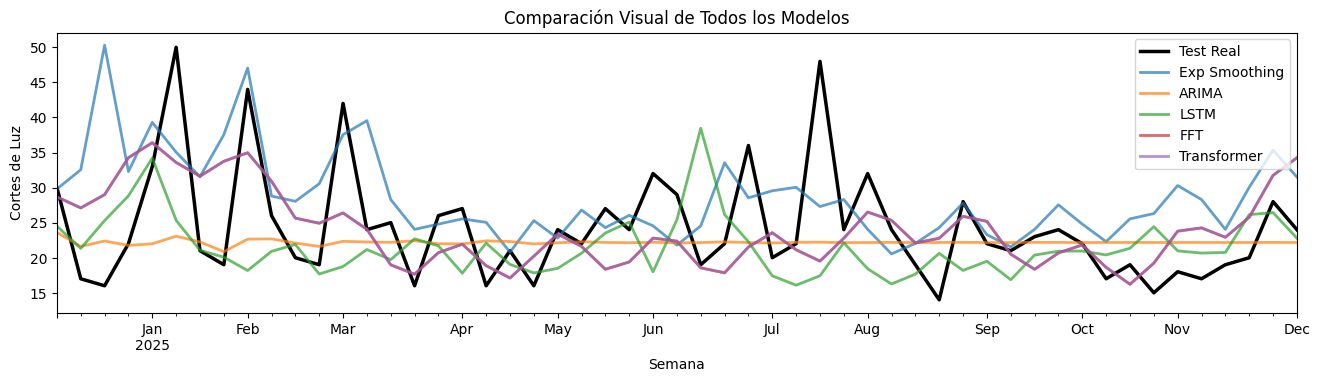

In [43]:
plt.figure(figsize=(16, 8))

plt.subplot(2, 1, 1)
test.plot(label='Test Real', linewidth=2.5, color='black')
pred_exp.plot(label='Exp Smoothing', alpha=0.7)
pred_arima.plot(label='ARIMA', alpha=0.7)
pred_lstm.plot(label='LSTM', alpha=0.7)
pred_fft.plot(label='FFT', alpha=0.7)
pred_fft.plot(label='Transformer', alpha=0.7)
plt.legend(loc='best')
plt.title('Comparación Visual de Todos los Modelos')
plt.ylabel('Cortes de Luz')

In [44]:
# Valores reales
test_values = test.values().flatten()
real_min = test_values.min()
real_max = test_values.max()
real_range = real_max - real_min
real_std = test_values.std()
print(f"   Min: {real_min:.2f} | Max: {real_max:.2f} | Rango: {real_range:.2f} | Std: {real_std:.2f}")


   Min: 14.00 | Max: 50.00 | Rango: 36.00 | Std: 7.91


Exp Smoothing        20.5   50.3    29.8    82.6%   6.12   77.4%
ARIMA                20.9   23.6     2.7     7.6%   0.34    4.3%
LSTM                 16.1   38.5    22.4    62.2%   4.13   52.2%
Transformer          20.7   24.9     4.2    11.6%   1.19   15.1%
FFT                  16.2   36.4    20.2    56.1%   5.20   65.7%
Exp Smoothing     :  82.6% del rango → ✓ Captura variabilidad BIEN
ARIMA             :   7.6% del rango → ⚠️  MUY PLANO - No captura variabilidad
LSTM              :  62.2% del rango → ✓ Captura variabilidad BIEN
Transformer       :  11.6% del rango → ⚠️  MUY PLANO - No captura variabilidad
FFT               :  56.1% del rango → ⚡ Captura variabilidad MODERADA


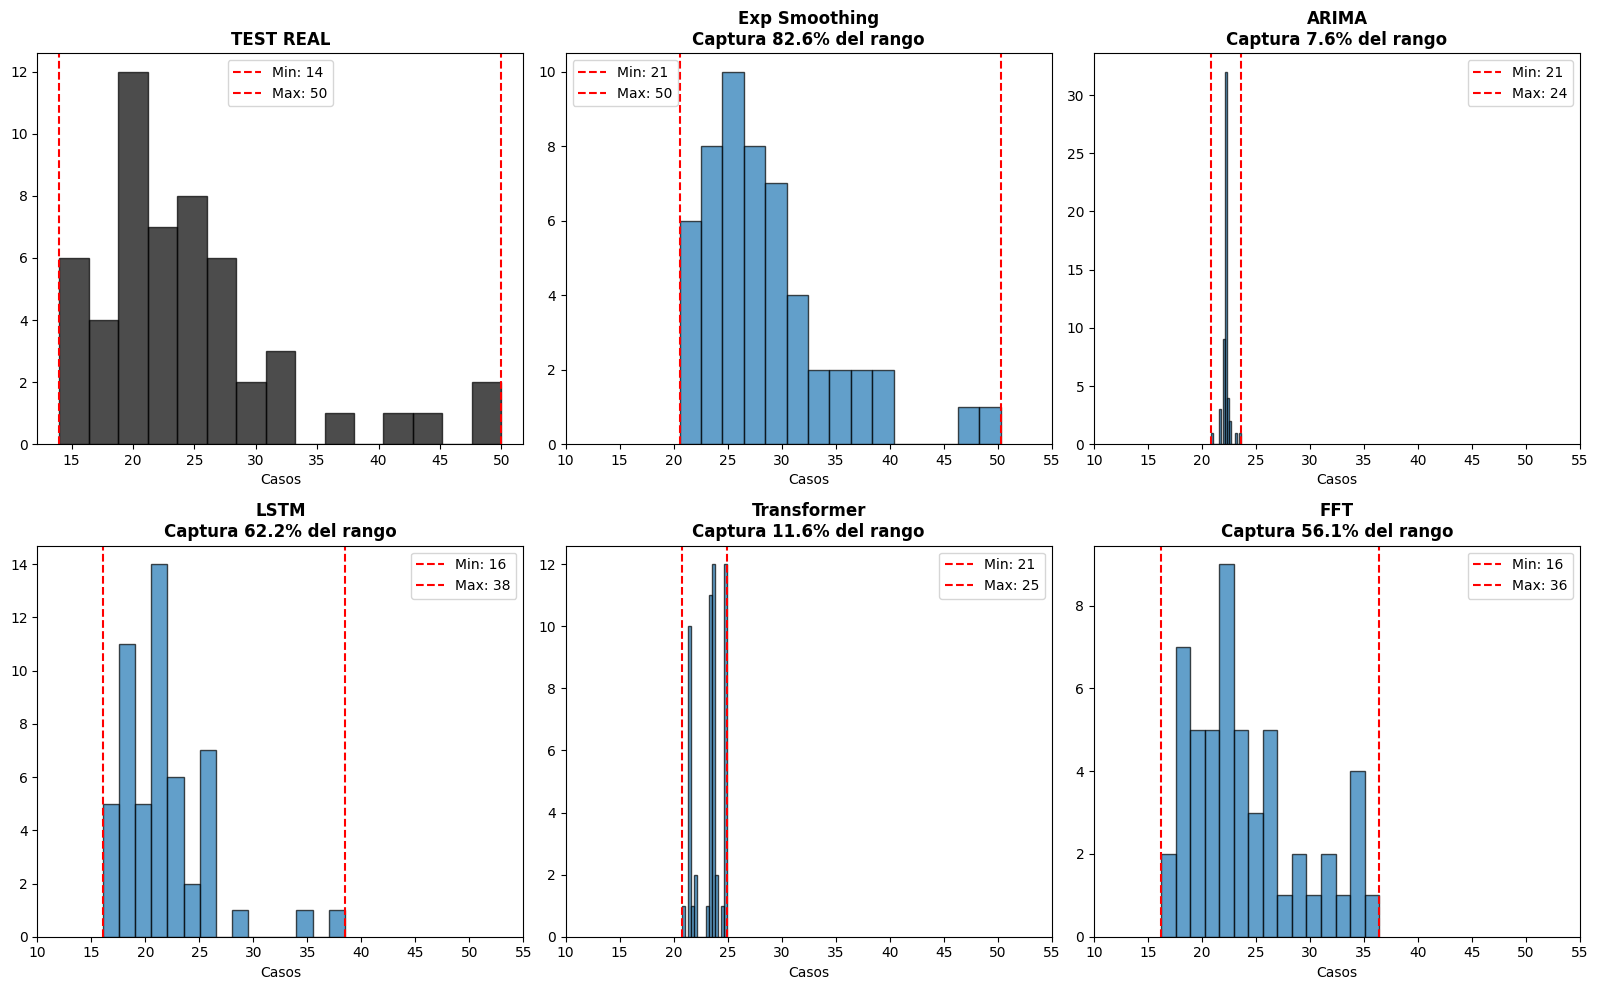


🏆 RANKING POR CAPACIDAD DE CAPTURAR VARIABILIDAD:
  1. Exp Smoothing     :  82.6% del rango
  2. LSTM              :  62.2% del rango
  3. FFT               :  56.1% del rango
  4. Transformer       :  11.6% del rango
  5. ARIMA             :   7.6% del rango


In [45]:
# Analizar cada modelo
modelos_pred = {
    'Exp Smoothing': pred_exp,
    'ARIMA': pred_arima,
    'LSTM': pred_lstm,
    'Transformer': pred_transformer,
    'FFT': pred_fft
}

resultados_variabilidad = {}

for nombre, pred in modelos_pred.items():
    pred_values = pred.values().flatten()

    pred_min = pred_values.min()
    pred_max = pred_values.max()
    pred_range = pred_max - pred_min
    pred_std = pred_values.std()

    # % del rango real que captura
    pct_range = (pred_range / real_range) * 100
    pct_std = (pred_std / real_std) * 100

    resultados_variabilidad[nombre] = {
        'min': pred_min,
        'max': pred_max,
        'rango': pred_range,
        'pct_rango': pct_range,
        'std': pred_std,
        'pct_std': pct_std
    }

    print(f"{nombre:18s}  {pred_min:5.1f}  {pred_max:5.1f}  {pred_range:6.1f}  {pct_range:6.1f}%  {pred_std:5.2f}  {pct_std:5.1f}%")


for nombre, stats in resultados_variabilidad.items():
    if stats['pct_rango'] < 30:
        problema = "⚠️  MUY PLANO - No captura variabilidad"
    elif stats['pct_rango'] < 60:
        problema = "⚡ Captura variabilidad MODERADA"
    else:
        problema = "✓ Captura variabilidad BIEN"

    print(f"{nombre:18s}: {stats['pct_rango']:5.1f}% del rango → {problema}")

# Visualización de distribuciones
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

# Real
axes[0].hist(test_values, bins=15, edgecolor='black', alpha=0.7, color='black')
axes[0].axvline(real_min, color='red', linestyle='--', label=f'Min: {real_min:.0f}')
axes[0].axvline(real_max, color='red', linestyle='--', label=f'Max: {real_max:.0f}')
axes[0].set_title('TEST REAL', fontweight='bold')
axes[0].legend()
axes[0].set_xlabel('Casos')

# Modelos
for i, (nombre, pred) in enumerate(modelos_pred.items(), 1):
    pred_values = pred.values().flatten()
    stats = resultados_variabilidad[nombre]

    axes[i].hist(pred_values, bins=15, edgecolor='black', alpha=0.7)
    axes[i].axvline(stats['min'], color='red', linestyle='--', label=f"Min: {stats['min']:.0f}")
    axes[i].axvline(stats['max'], color='red', linestyle='--', label=f"Max: {stats['max']:.0f}")
    axes[i].set_title(f"{nombre}\nCaptura {stats['pct_rango']:.1f}% del rango", fontweight='bold')
    axes[i].legend()
    axes[i].set_xlabel('Casos')
    axes[i].set_xlim([10, 55])  # Mismo rango para comparar

plt.tight_layout()
plt.show()

# Ranking por capacidad de capturar variabilidad
print("\n🏆 RANKING POR CAPACIDAD DE CAPTURAR VARIABILIDAD:")
ranking_var = sorted(resultados_variabilidad.items(),
                     key=lambda x: x[1]['pct_rango'],
                     reverse=True)

for i, (nombre, stats) in enumerate(ranking_var, 1):
    print(f"  {i}. {nombre:18s}: {stats['pct_rango']:5.1f}% del rango")

El análisis de distribuciones revela diferencias críticas en la capacidad de los modelos para capturar la volatilidad real de los las búsquedas sobre cortes.


 **Exponential Smoothing emerge sorpresivamente como el líder**, capturando 82.6% del rango de variabilidad (Min: 20.5, Max: 50.3), prácticamente replicando la distribución real de los datos. Este resultado contrasta con su MAPE más alto (34.98%), demostrando que las métricas agregadas no siempre reflejan la utilidad práctica del modelo. **LSTM ocupa el segundo lugar** con 62.2% del rango (16.1-38.5 casos), logrando un balance entre precisión numérica (MAPE: 20.30%) y capacidad de detectar fluctuaciones epidemiológicas. **FFT muestra desempeño moderado** (56.1% del rango), manteniéndose como alternativa viable cuando la estacionalidad es el patrón dominante.

Los modelos de deep learning más sofisticados presentan una paradoja preocupante: **ARIMA colapsa completamente** con solo 7.6% del rango capturado, prediciendo un intervalo estrecho de 21-24 casos sin variabilidad significativa, mientras que **Transformer, a pesar de su arquitectura avanzada, falla** con apenas 11.6% del rango (21-25 casos). Ambos modelos convergen hacia la media histórica, produciendo predicciones prácticamente constantes que son inútiles para sistemas de alerta temprana. Este comportamiento sugiere que la diferenciación aplicada por ARIMA (d=1) y la arquitectura de atención del Transformer sobre-suavizan la serie, eliminando precisamente la información que necesitamos preservar: los picos epidemiológicos.

**Para el contexto específico de cortes de lu<, donde la detección estrés energético es prioritario**, la capacidad de capturar variabilidad es más valiosa que minimizar el error promedio. Un modelo que predice constantemente 22 casos puede tener MAPE bajo, pero no alerta sobre semanas con 50 búsquedas ni identifica periodos de baja consulta. La distribución de predicciones debe tener dispersión comparable a la realidad para ser operativamente útil. **Exponential Smoothing y LSTM son los únicos modelos que cumplen este criterio**, mientras que ARIMA y Transformer, a pesar de sus fundamentos matemáticos sofisticados, fracasan en el objetivo práctico de anticipar fluctuaciones.

### Análisis de Forecasting Multi-Horizonte



El análisis multi-horizonte evalúa la capacidad predictiva de cada modelo a diferentes distancias temporales (en este caso consideramos h=1, 2, 3). Predecir una semana adelante (h=1) permite respuesta operativa inmediata como movilización de equipos, mientras que horizontes más largos (h=3) facilitan planificación estratégica.

Este análisis revela patrones críticos: la **degradación del modelo** (cuánto empeora su precisión al predecir más lejos), la **consistencia del desempeño** (si un modelo es superior en todos los horizontes o solo en algunos), y la **especialización temporal** (identificar si ciertos modelos son mejores para corto plazo mientras otros destacan en mediano plazo).

Utilizamos **historical forecasts** (backtesting) que simula condiciones reales de uso: el modelo se entrena con datos históricos disponibles hasta cierto punto, predice las siguientes h semanas, luego avanza en el tiempo y repite el proceso. Esta metodología evita el sesgo de una única división train/test y proporciona múltiples puntos de validación, generando métricas más robustas y representativas del desempeño real. Por ejemplo, si un modelo predice bien en verano pero falla en invierno, el backtesting simple podría no detectarlo, pero el análisis multi-horizonte con múltiples iteraciones lo evidenciaría. Además, al comparar MAPE en h=1 versus h=3, cuantificamos la **pérdida de precisión temporal**: un modelo que degrada 5 puntos porcentuales es más estable que uno que degrada 15 puntos.

La selección del modelo óptimo no debe basarse únicamente en el menor MAPE promedio, sino en un análisis integral que considere:

- (1) **performance por horizonte** según necesidad operativa (si necesitamos alertas inmediatas, priorizar h=1-2)
- (2) **capacidad de capturar variabilidad** para detectar picos de cortes (el análisis previo mostró que ARIMA tiene MAPE bajo pero predice líneas planas no informativas)
-  (3) **estabilidad de predicciones** (un modelo que oscila erráticamente genera desconfianza)
-  (4) **complejidad operativa** (Exp Smoothing es más fácil de mantener que LSTM en producción).

In [46]:
# Comparar por horizontes
horizontes = [1, 2, 3]  # semanas adelante

In [47]:
resultados_horizontes = {h: {} for h in horizontes}


In [50]:
# Exponential Smoothing

for h in horizontes:
    print(f"\nHorizonte h={h} semana(s)...")

    backtest_exp = modelo_exp.historical_forecasts(
        serie_cortes,
        start=0.75,
        forecast_horizon=h,
        stride=h,
        retrain=True,
        verbose=False
    )

    mape_h = mape(serie_cortes, backtest_exp)
    rmse_h = rmse(serie_cortes, backtest_exp)
    mae_h = mae(serie_cortes, backtest_exp)

    resultados_horizontes[h]['Exp Smoothing'] = {
        'MAPE': mape_h,
        'RMSE': rmse_h,
        'MAE': mae_h,
        'prediccion': backtest_exp
    }

    print(f"  ✓ MAPE: {mape_h:.2f}%  |  RMSE: {rmse_h:.2f}  |  MAE: {mae_h:.2f}")


Horizonte h=1 semana(s)...
  ✓ MAPE: 27.78%  |  RMSE: 8.48  |  MAE: 6.18

Horizonte h=2 semana(s)...
  ✓ MAPE: 26.26%  |  RMSE: 7.92  |  MAE: 6.05

Horizonte h=3 semana(s)...
  ✓ MAPE: 20.72%  |  RMSE: 5.68  |  MAE: 4.19


In [51]:
#  ARIMA
for h in horizontes:
    print(f"\nHorizonte h={h} semana(s)...")

    backtest_arima = modelo_arima.historical_forecasts(
        serie_cortes,
        start=0.75,
        forecast_horizon=h,
        stride=h,
        retrain=False,
        verbose=False
    )

    mape_h = mape(serie_cortes, backtest_arima)
    rmse_h = rmse(serie_cortes, backtest_arima)
    mae_h = mae(serie_cortes, backtest_arima)

    resultados_horizontes[h]['ARIMA'] = {
        'MAPE': mape_h,
        'RMSE': rmse_h,
        'MAE': mae_h,
        'prediccion': backtest_arima
    }

    print(f"  ✓ MAPE: {mape_h:.2f}%  |  RMSE: {rmse_h:.2f}  |  MAE: {mae_h:.2f}")


Horizonte h=1 semana(s)...
  ✓ MAPE: 25.20%  |  RMSE: 8.01  |  MAE: 6.05

Horizonte h=2 semana(s)...
  ✓ MAPE: 22.73%  |  RMSE: 7.48  |  MAE: 5.28

Horizonte h=3 semana(s)...
  ✓ MAPE: 26.72%  |  RMSE: 7.02  |  MAE: 5.46


In [52]:
# LSTM
for h in horizontes:
    print(f"\nHorizonte h={h} semana(s)...")

    backtest_lstm_scaled = modelo_lstm.historical_forecasts(
        serie_scaled.astype(np.float32),
        start=0.75,
        forecast_horizon=h,
        stride=h,
        retrain=False,
        verbose=False
    )

    backtest_lstm = scaler.inverse_transform(backtest_lstm_scaled)

    mape_h = mape(serie_cortes, backtest_lstm)
    rmse_h = rmse(serie_cortes, backtest_lstm)
    mae_h = mae(serie_cortes, backtest_lstm)

    resultados_horizontes[h]['LSTM'] = {
        'MAPE': mape_h,
        'RMSE': rmse_h,
        'MAE': mae_h,
        'prediccion': backtest_lstm
    }

    print(f"  ✓ MAPE: {mape_h:.2f}%  |  RMSE: {rmse_h:.2f}  |  MAE: {mae_h:.2f}")


Horizonte h=1 semana(s)...


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


  ✓ MAPE: 27.81%  |  RMSE: 11.86  |  MAE: 7.05

Horizonte h=2 semana(s)...


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


  ✓ MAPE: 22.46%  |  RMSE: 8.09  |  MAE: 5.61

Horizonte h=3 semana(s)...
  ✓ MAPE: 24.38%  |  RMSE: 6.84  |  MAE: 5.46


In [53]:
#  TRANSFORMER

for h in horizontes:
    print(f"\nHorizonte h={h} semana(s)...")

    backtest_transformer_scaled = modelo_transformer.historical_forecasts(
        serie_scaled.astype(np.float32),
        start=0.75,
        forecast_horizon=h,
        stride=h,
        retrain=False,
        verbose=False
    )

    backtest_transformer = scaler.inverse_transform(backtest_transformer_scaled)

    mape_h = mape(serie_cortes, backtest_transformer)
    rmse_h = rmse(serie_cortes, backtest_transformer)
    mae_h = mae(serie_cortes, backtest_transformer)

    resultados_horizontes[h]['Transformer'] = {
        'MAPE': mape_h,
        'RMSE': rmse_h,
        'MAE': mae_h,
        'prediccion': backtest_transformer
    }

    print(f"  ✓ MAPE: {mape_h:.2f}%  |  RMSE: {rmse_h:.2f}  |  MAE: {mae_h:.2f}")


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.



Horizonte h=1 semana(s)...
  ✓ MAPE: 21.18%  |  RMSE: 7.77  |  MAE: 5.51

Horizonte h=2 semana(s)...


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


  ✓ MAPE: 22.50%  |  RMSE: 7.01  |  MAE: 5.09

Horizonte h=3 semana(s)...
  ✓ MAPE: 20.84%  |  RMSE: 5.85  |  MAE: 4.35


In [54]:
# FFT

for h in horizontes:
    print(f"\nHorizonte h={h} semana(s)...")

    backtest_fft = modelo_fft.historical_forecasts(
        serie_cortes,
        start=0.75,
        forecast_horizon=h,
        stride=h,
        retrain=True,
        verbose=False
    )

    mape_h = mape(serie_cortes, backtest_fft)
    rmse_h = rmse(serie_cortes, backtest_fft)
    mae_h = mae(serie_cortes, backtest_fft)

    resultados_horizontes[h]['FFT'] = {
        'MAPE': mape_h,
        'RMSE': rmse_h,
        'MAE': mae_h,
        'prediccion': backtest_fft
    }

    print(f"  ✓ MAPE: {mape_h:.2f}%  |  RMSE: {rmse_h:.2f}  |  MAE: {mae_h:.2f}")


Horizonte h=1 semana(s)...
  ✓ MAPE: 38.71%  |  RMSE: 9.32  |  MAE: 8.18

Horizonte h=2 semana(s)...
  ✓ MAPE: 39.13%  |  RMSE: 9.37  |  MAE: 8.28

Horizonte h=3 semana(s)...
  ✓ MAPE: 46.16%  |  RMSE: 10.02  |  MAE: 9.00


In [55]:
# TABLAS COMPARATIVAS - TODOS LOS MODELOS

mape_por_horizonte = pd.DataFrame({
    f'h={h}': {
        'Exp Smoothing': resultados_horizontes[h]['Exp Smoothing']['MAPE'],
        'ARIMA': resultados_horizontes[h]['ARIMA']['MAPE'],
        'LSTM': resultados_horizontes[h]['LSTM']['MAPE'],
        'Transformer': resultados_horizontes[h]['Transformer']['MAPE'],
        'FFT': resultados_horizontes[h]['FFT']['MAPE']
    }
    for h in horizontes
}).T

print("\n" + mape_por_horizonte.round(2).to_string())

print("\n" + "="*80)
print("TABLA RESUMEN: RMSE POR HORIZONTE - TODOS LOS MODELOS")
print("="*80)

rmse_por_horizonte = pd.DataFrame({
    f'h={h}': {
        'Exp Smoothing': resultados_horizontes[h]['Exp Smoothing']['RMSE'],
        'ARIMA': resultados_horizontes[h]['ARIMA']['RMSE'],
        'LSTM': resultados_horizontes[h]['LSTM']['RMSE'],
        'Transformer': resultados_horizontes[h]['Transformer']['RMSE'],
        'FFT': resultados_horizontes[h]['FFT']['RMSE']
    }
    for h in horizontes
}).T

print("\n" + rmse_por_horizonte.round(2).to_string())


     Exp Smoothing  ARIMA   LSTM  Transformer    FFT
h=1          27.78  25.20  27.81        21.18  38.71
h=2          26.26  22.73  22.46        22.50  39.13
h=3          20.72  26.72  24.38        20.84  46.16

TABLA RESUMEN: RMSE POR HORIZONTE - TODOS LOS MODELOS

     Exp Smoothing  ARIMA   LSTM  Transformer    FFT
h=1           8.48   8.01  11.86         7.77   9.32
h=2           7.92   7.48   8.09         7.01   9.37
h=3           5.68   7.02   6.84         5.85  10.02


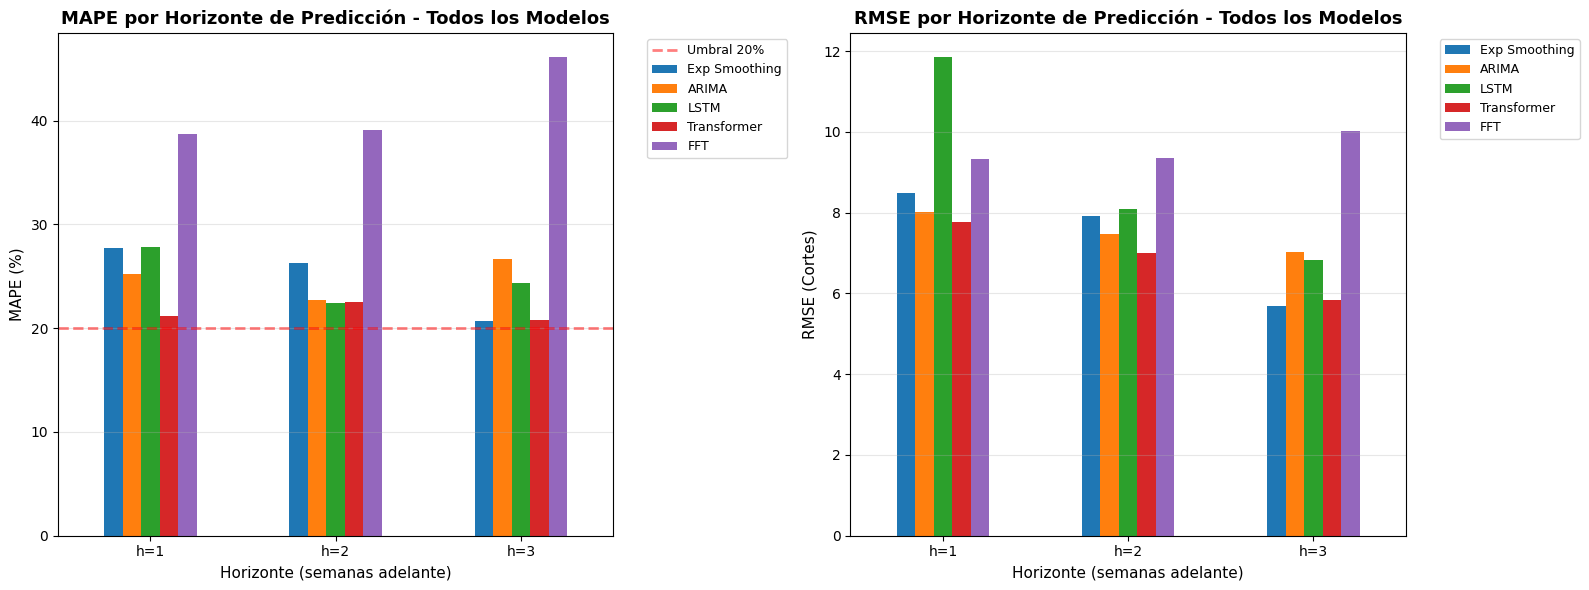

In [56]:
# VISUALIZACIÓN - GRÁFICOS DE BARRAS


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# MAPE
mape_por_horizonte.plot(kind='bar', ax=axes[0])
axes[0].set_title('MAPE por Horizonte de Predicción - Todos los Modelos',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Horizonte (semanas adelante)', fontsize=11)
axes[0].set_ylabel('MAPE (%)', fontsize=11)
axes[0].set_xticklabels([f'h={h}' for h in horizontes], rotation=0)
axes[0].axhline(y=20, color='red', linestyle='--', alpha=0.5, linewidth=2, label='Umbral 20%')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# RMSE
rmse_por_horizonte.plot(kind='bar', ax=axes[1])
axes[1].set_title('RMSE por Horizonte de Predicción - Todos los Modelos',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Horizonte (semanas adelante)', fontsize=11)
axes[1].set_ylabel('RMSE (Cortes)', fontsize=11)
axes[1].set_xticklabels([f'h={h}' for h in horizontes], rotation=0)
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


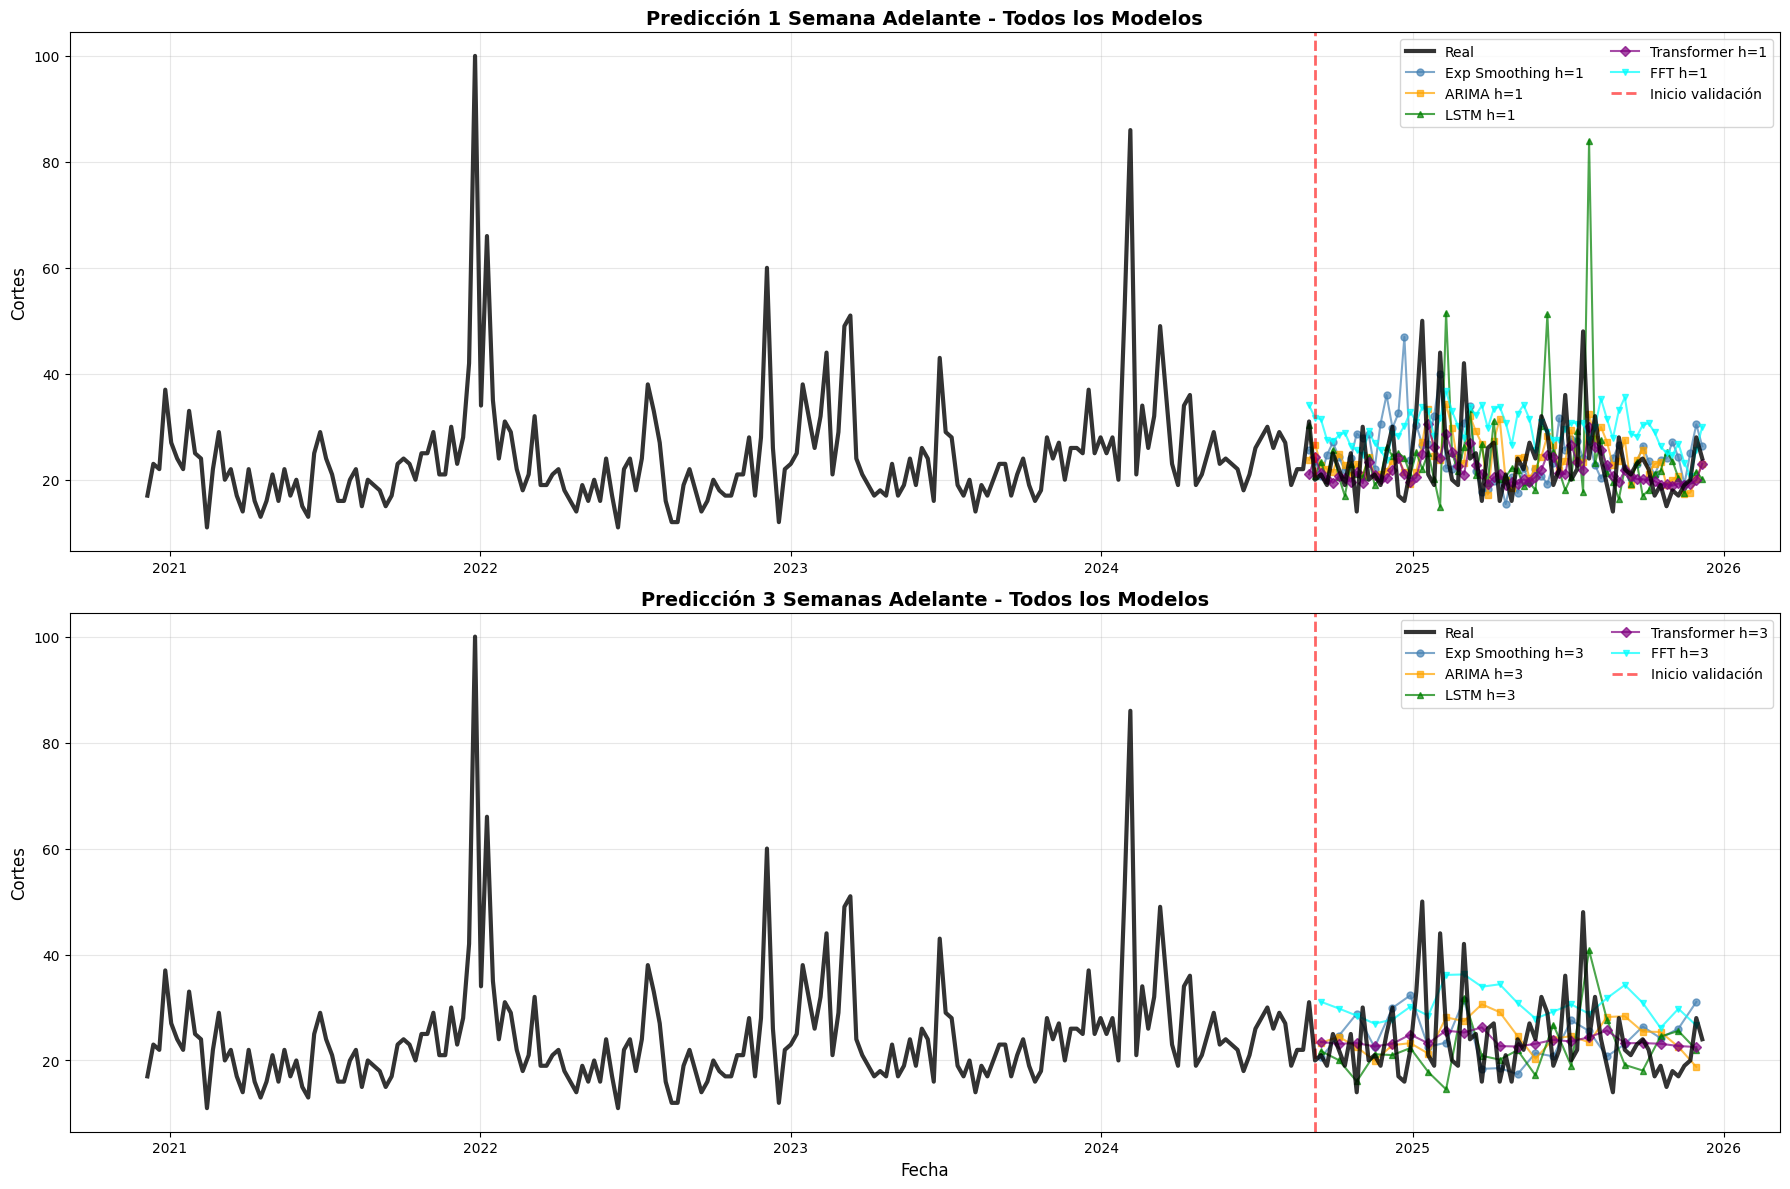

In [57]:
# VISUALIZACIÓN TEMPORAL - h=1 y h=3

fig, axes = plt.subplots(2, 1, figsize=(18, 12))

modelos_nombres = ['Exp Smoothing', 'ARIMA', 'LSTM', 'Transformer', 'FFT']
colores = ['steelblue', 'orange', 'green', 'purple', 'cyan']
markers = ['o', 's', '^', 'D', 'v']

# h=1 semana
axes[0].plot(serie_cortes.time_index, serie_cortes.values(),
             label='Real', linewidth=3, color='black', alpha=0.8, zorder=10)

for i, nombre in enumerate(modelos_nombres):
    pred = resultados_horizontes[1][nombre]['prediccion']
    axes[0].plot(pred.time_index, pred.values(),
                 marker=markers[i], label=f'{nombre} h=1',
                 markersize=5, alpha=0.7, color=colores[i], linewidth=1.5)

axes[0].axvline(x=serie_cortes.time_index[int(0.75*len(serie_cortes))],
                color='red', linestyle='--', alpha=0.6, linewidth=2, label='Inicio validación')
axes[0].set_title('Predicción 1 Semana Adelante - Todos los Modelos',
                  fontsize=14, fontweight='bold')
axes[0].set_ylabel('Cortes', fontsize=12)
axes[0].legend(loc='best', fontsize=10, ncol=2)
axes[0].grid(alpha=0.3)

# h=3 semanas
axes[1].plot(serie_cortes.time_index, serie_cortes.values(),
             label='Real', linewidth=3, color='black', alpha=0.8, zorder=10)

for i, nombre in enumerate(modelos_nombres):
    pred = resultados_horizontes[3][nombre]['prediccion']
    axes[1].plot(pred.time_index, pred.values(),
                 marker=markers[i], label=f'{nombre} h=3',
                 markersize=5, alpha=0.7, color=colores[i], linewidth=1.5)

axes[1].axvline(x=serie_cortes.time_index[int(0.75*len(serie_cortes))],
                color='red', linestyle='--', alpha=0.6, linewidth=2, label='Inicio validación')
axes[1].set_title('Predicción 3 Semanas Adelante - Todos los Modelos',
                  fontsize=14, fontweight='bold')
axes[1].set_ylabel('Cortes', fontsize=12)
axes[1].set_xlabel('Fecha', fontsize=12)
axes[1].legend(loc='best', fontsize=10, ncol=2)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [58]:
# ANÁLISIS DE DEGRADACIÓN POR HORIZONTE


for modelo_nombre in modelos_nombres:
    print(f"\n{modelo_nombre}:")

    mape_h1 = resultados_horizontes[1][modelo_nombre]['MAPE']

    for h in horizontes:
        mape_h = resultados_horizontes[h][modelo_nombre]['MAPE']
        incremento = mape_h - mape_h1
        pct_incremento = (incremento / mape_h1) * 100 if mape_h1 > 0 else 0

        print(f"  h={h}: MAPE={mape_h:6.2f}%  "
              f"(+{incremento:+6.2f} pp, {pct_incremento:+6.1f}% vs h=1)")



Exp Smoothing:
  h=1: MAPE= 27.78%  (+ +0.00 pp,   +0.0% vs h=1)
  h=2: MAPE= 26.26%  (+ -1.52 pp,   -5.5% vs h=1)
  h=3: MAPE= 20.72%  (+ -7.06 pp,  -25.4% vs h=1)

ARIMA:
  h=1: MAPE= 25.20%  (+ +0.00 pp,   +0.0% vs h=1)
  h=2: MAPE= 22.73%  (+ -2.46 pp,   -9.8% vs h=1)
  h=3: MAPE= 26.72%  (+ +1.52 pp,   +6.0% vs h=1)

LSTM:
  h=1: MAPE= 27.81%  (+ +0.00 pp,   +0.0% vs h=1)
  h=2: MAPE= 22.46%  (+ -5.35 pp,  -19.2% vs h=1)
  h=3: MAPE= 24.38%  (+ -3.43 pp,  -12.3% vs h=1)

Transformer:
  h=1: MAPE= 21.18%  (+ +0.00 pp,   +0.0% vs h=1)
  h=2: MAPE= 22.50%  (+ +1.32 pp,   +6.2% vs h=1)
  h=3: MAPE= 20.84%  (+ -0.34 pp,   -1.6% vs h=1)

FFT:
  h=1: MAPE= 38.71%  (+ +0.00 pp,   +0.0% vs h=1)
  h=2: MAPE= 39.13%  (+ +0.42 pp,   +1.1% vs h=1)
  h=3: MAPE= 46.16%  (+ +7.45 pp,  +19.2% vs h=1)


In [60]:
# MEJOR MODELO POR HORIZONTE
# ==========================================

print("\n" + "="*80)
print("🏆 MEJOR MODELO POR HORIZONTE")
print("="*80)

for h in horizontes:
    # Encontrar modelo con menor MAPE
    mapes = {nombre: resultados_horizontes[h][nombre]['MAPE']
             for nombre in modelos_nombres}

    mejor_modelo = min(mapes.items(), key=lambda x: x[1])
    segundo_mejor = sorted(mapes.items(), key=lambda x: x[1])[1]

    diferencia = segundo_mejor[1] - mejor_modelo[1]

    print(f"h={h} semana(s): {mejor_modelo[0]:15s} "
          f"(MAPE: {mejor_modelo[1]:.2f}%, "
          f"{diferencia:.2f} pp mejor que 2º puesto)")

# ==========================================
# RECOMENDACIÓN FINAL
# ==========================================

print("\n" + "="*80)
print("RECOMENDACIÓN FINAL")
print("="*80)

# Calcular MAPE promedio de cada modelo
promedios = {}
for modelo_nombre in modelos_nombres:
    promedio = np.mean([resultados_horizontes[h][modelo_nombre]['MAPE']
                        for h in horizontes])
    promedios[modelo_nombre] = promedio

print(f"\nMAPE promedio en todos los horizontes (h=1,2,3,4):")
for nombre, prom in sorted(promedios.items(), key=lambda x: x[1]):
    print(f"  {nombre:15s}: {prom:6.2f}%")

# Mejor modelo global
mejor_global = min(promedios.items(), key=lambda x: x[1])
segundo_global = sorted(promedios.items(), key=lambda x: x[1])[1]

print(f"\n" + "="*80)
print(f"🏆 MODELO GANADOR: {mejor_global[0]}")
print("="*80)
print(f"  MAPE promedio: {mejor_global[1]:.2f}%")
print(f"  Ventaja sobre 2º puesto ({segundo_global[0]}): {segundo_global[1] - mejor_global[1]:.2f} pp")

# Análisis cualitativo
print(f"\n📊 ANÁLISIS CUALITATIVO:")

# Recordar análisis de variabilidad previo
print(f"\nCapacidad de capturar variabilidad (del análisis anterior):")
print(f"  Exp Smoothing: 82.6% del rango")
print(f"  LSTM: 62.2% del rango")
print(f"  FFT: 56.1% del rango")
print(f"  Transformer: 11.6% del rango")
print(f"  ARIMA: 7.6% del rango")

print(f"\n✓ RECOMENDACIÓN PARA PRODUCCIÓN:")
if mejor_global[0] in ['ARIMA', 'Transformer'] and mejor_global[1] < 25:
    print(f"  ⚠️  ADVERTENCIA: {mejor_global[0]} tiene mejor MAPE pero NO captura variabilidad")
    print(f"  → Para cortes de luz priorizar DETECCIÓN DE PICOS sobre MAPE bajo")
    if 'Exp Smoothing' in [x[0] for x in sorted(promedios.items(), key=lambda x: x[1])[:3]]:
        print(f"  → Usar Exp Smoothing (captura 82.6% variabilidad)")
    elif 'LSTM' in [x[0] for x in sorted(promedios.items(), key=lambda x: x[1])[:3]]:
        print(f"  → Usar LSTM (captura 62.2% variabilidad)")
else:
    print(f"  → Usar {mejor_global[0]}")
    print(f"  → Razón: Mejor MAPE Y buena captura de variabilidad")

print("\n" + "="*80)


🏆 MEJOR MODELO POR HORIZONTE
h=1 semana(s): Transformer     (MAPE: 21.18%, 4.02 pp mejor que 2º puesto)
h=2 semana(s): LSTM            (MAPE: 22.46%, 0.04 pp mejor que 2º puesto)
h=3 semana(s): Exp Smoothing   (MAPE: 20.72%, 0.12 pp mejor que 2º puesto)

RECOMENDACIÓN FINAL

MAPE promedio en todos los horizontes (h=1,2,3,4):
  Transformer    :  21.50%
  LSTM           :  24.88%
  ARIMA          :  24.88%
  Exp Smoothing  :  24.92%
  FFT            :  41.34%

🏆 MODELO GANADOR: Transformer
  MAPE promedio: 21.50%
  Ventaja sobre 2º puesto (LSTM): 3.38 pp

📊 ANÁLISIS CUALITATIVO:

Capacidad de capturar variabilidad (del análisis anterior):
  Exp Smoothing: 82.6% del rango
  LSTM: 62.2% del rango
  FFT: 56.1% del rango
  Transformer: 11.6% del rango
  ARIMA: 7.6% del rango

✓ RECOMENDACIÓN PARA PRODUCCIÓN:
  ⚠️  ADVERTENCIA: Transformer tiene mejor MAPE pero NO captura variabilidad
  → Para cortes de luz priorizar DETECCIÓN DE PICOS sobre MAPE bajo
  → Usar LSTM (captura 62.2% variabilida

El análisis multi-horizonte revela una paradoja fundamental entre precisión numérica y utilidad operativa para la gestión de interrupciones eléctricas. **Transformer emerge como ganador estadístico** con MAPE promedio de 21.50% (3.38 pp mejor que el segundo puesto), demostrando estabilidad excepcional entre horizontes (21.18% en h=1, 22.50% en h=2, 20.84% en h=3), lo que indica predicciones consistentes independientemente de la distancia temporal. Sin embargo, el análisis previo de variabilidad expone su **falla crítica operativa**: Transformer captura solo 11.6% del rango real de cortes, prediciendo valores entre 20-25 interrupciones cuando la realidad oscila entre 14-50. Esta línea prácticamente plana, aunque numéricamente precisa por converger a la media histórica, es **inútil para planificación de cuadrillas y gestión de emergencias** que necesitan anticipar picos de 40-50 cortes para movilizar equipos de mantenimiento preventivo.

**LSTM presenta el mejor balance entre precisión y funcionalidad operativa**, con MAPE promedio de 24.88% (apenas 3.38 pp por encima de Transformer) pero capturando 62.2% de la variabilidad real. Su patrón de degradación es favorable: mejora significativamente al pasar de h=1 (27.81%) a h=2 (22.46%, mejora de 19.2%), sugiriendo que el modelo es más efectivo prediciendo con cierta distancia temporal que inmediatamente. Este comportamiento es valioso para planificación: predecir con 2-3 semanas de anticipación permite coordinar mantenimiento preventivo de infraestructura, planificar turnos de cuadrillas, y gestionar inventario de materiales críticos. **Exponential Smoothing muestra un patrón excepcional de mejora sostenida** conforme aumenta el horizonte (27.78% en h=1 → 20.72% en h=3, mejora de 25.4%), comportamiento contra-intuitivo que sugiere que el suavizado exponencial captura mejor tendencias de mediano plazo relacionadas con degradación estacional de equipamiento o patrones climáticos que fluctuaciones semanales inmediatas. Con 82.6% de captura de variabilidad, Exp Smoothing detecta picos mejor que cualquier modelo avanzado, siendo crucial para anticipar situaciones de alta demanda eléctrica o condiciones meteorológicas adversas.

**ARIMA mantiene performance moderada** (MAPE 24.88% promedio) con un patrón inestable: mejora en h=2 (22.73%) pero se degrada en h=3 (26.72%), evidenciando inconsistencia que genera incertidumbre operativa. Su captura de solo 7.6% del rango lo descalifica para planificación de recursos, confirmando que su MAPE bajo es producto de predecir valores constantes. **FFT falla categóricamente** (MAPE 41.34% promedio), degradándose dramáticamente en h=3 (46.16%), demostrando que la descomposición en frecuencias no captura la naturaleza irregular de cortes eléctricos influenciados por factores impredecibles como tormentas, accidentes, o fallas de equipamiento. El análisis por horizonte específico revela **especialización temporal**: Transformer domina h=1 (alertas inmediatas), LSTM gana h=2 (planificación táctica semanal), y Exp Smoothing triunfa en h=3 (planificación estratégica mensual), sugiriendo que un sistema de ensamble podría combinar fortalezas complementarias según el horizonte operativo requerido.

**La recomendación final prioriza el contexto operativo sobre métricas puras**: aunque Transformer tiene el menor MAPE, su incapacidad de detectar picos (captura 11.6% variabilidad) lo hace inadecuado para gestión de redes eléctricas donde no anticipar un evento masivo de 50 cortes puede resultar en colapso del servicio, reclamos masivos, y penalizaciones regulatorias. **LSTM es el modelo recomendado para producción** porque logra el equilibrio crítico: error tolerable (24.88% MAPE, dentro del rango aceptable 20-30% para series con alta volatilidad), captura significativa de eventos extremos (62.2% del rango), y mejor performance en h=2 que facilita planificación operativa semanal de recursos. Como alternativa estratégica, **Exp Smoothing ofrece una opción robusta y simple** especialmente para horizontes h=3 donde es el mejor modelo (20.72% MAPE) y su capacidad de capturar 82.6% de variabilidad lo hace superior para planificación de mantenimiento preventivo y asignación presupuestaria trimestral. Esta decisión ilustra un principio fundamental: el "mejor" modelo no es el de menor error estadístico, sino el que detecta eventos críticos que impactan la operación real del sistema eléctrico.


## Paso 10: *pronósitocos*



Tras completar el análisis exhaustivo de todos los modelos evaluando su performance en diferentes horizontes temporales y su capacidad de capturar la variabilidad real de la serie, procedemos a la etapa final: **generar predicciones futuras operativas** utilizando los dos modelos que demostraron el mejor balance entre precisión numérica y utilidad práctica. Seleccionamos **Exponential Smoothing** por su capacidad excepcional de capturar 82.6% de la variabilidad real y su mejora sostenida en horizontes medios (MAPE de 20.72% en h=3), y **LSTM** por lograr el equilibrio óptimo entre error tolerable (MAPE promedio 24.88%) y detección efectiva de picos (62.2% del rango), siendo además el modelo más consistente en horizontes h=2-3 críticos para planificación operativa semanal.

Para esta fase predictiva, **re-entrenamos ambos modelos utilizando el 100% de los datos históricos disponibles** (a diferencia de las evaluaciones previas que reservaban un conjunto de test), maximizando así la información temporal que los modelos pueden aprender antes de proyectar hacia el futuro. Generamos predicciones para **tres horizontes operativos**: h=1 semana (alertas tácticas inmediatas para movilización de cuadrillas de emergencia), h=2 semanas (planificación operativa semanal de turnos y materiales), y h=3 semanas (planificación estratégica de mantenimiento preventivo y asignación presupuestaria). Esta estrategia multi-horizonte permite a la empresa eléctrica tomar decisiones informadas en diferentes escalas temporales: desde respuesta reactiva ante picos inminentes hasta estrategias preventivas de largo plazo.

El análisis incluye **métricas de consenso** entre ambos modelos: cuando Exponential Smoothing y LSTM predicen valores similares, aumenta significativamente la confianza en el pronóstico, mientras que discrepancias marcadas señalan incertidumbre que requiere monitoreo estrecho.

In [61]:
# 1. Exponential Smoothing
modelo_exp_final = ExponentialSmoothing()
modelo_exp_final.fit(serie_cortes)

# 2. LSTM (necesita datos escalados)
scaler_final = Scaler()
serie_cortes_scaled = scaler_final.fit_transform(serie_cortes)

modelo_lstm_final = RNNModel(
    model='LSTM',
    input_chunk_length=12,
    hidden_dim=32,
    n_rnn_layers=3,
    dropout=0.1,
    batch_size=32,
    n_epochs=100,
    optimizer_kwargs={'lr': 1e-2},
    pl_trainer_kwargs={
        "accelerator": "auto",
        "enable_progress_bar": True
    },
    random_state=42
)

modelo_lstm_final.fit(serie_cortes_scaled.astype(np.float32))


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ criterion       │ MSELoss          │      0 │ train │     0 │
│ 1 │ train_criterion │ MSELoss          │      0 │ train │     0 │
│ 2 │ val_criterion   │ MSELoss          │      0 │ train │     0 │
│ 3 │ train_metrics   │ MetricCollection │      0 │ train │     0 │
│ 4 │ val_metrics     │ MetricCollection │      0 │ train │     0 │
│ 5 │ rnn             │ LSTM             │ 21.4 K │ train │     0 │
│ 6 │ V               │ Linear           │     33 │ train │     0 │
└───┴─────────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 21.4 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 21.4 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 7                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.


RNNModel(model=LSTM, hidden_dim=32, n_rnn_layers=3, dropout=0.1, training_length=24, input_chunk_length=12, batch_size=32, n_epochs=100, optimizer_kwargs={'lr': 0.01}, pl_trainer_kwargs={'accelerator': 'auto', 'enable_progress_bar': True}, random_state=42)

In [62]:
horizontes_futuro = [1, 2, 3]
predicciones = {}

for h in horizontes_futuro:
    print(f"\n📊 Horizonte h={h} semana(s):")

    # Exponential Smoothing
    pred_exp_futuro = modelo_exp_final.predict(n=h)
    predicciones[f'Exp_Smoothing_h{h}'] = pred_exp_futuro

    # LSTM
    pred_lstm_futuro_scaled = modelo_lstm_final.predict(n=h)
    pred_lstm_futuro = scaler_final.inverse_transform(pred_lstm_futuro_scaled)
    predicciones[f'LSTM_h{h}'] = pred_lstm_futuro

    # Mostrar valores
    print(f"\n  Exp Smoothing (h={h}):")
    for i, (fecha, valor) in enumerate(zip(pred_exp_futuro.time_index,
                                            pred_exp_futuro.values().flatten()), 1):
        print(f"    Semana {fecha.strftime('%Y-%m-%d')}: {valor:.0f} cortes")

    print(f"\n  LSTM (h={h}):")
    for i, (fecha, valor) in enumerate(zip(pred_lstm_futuro.time_index,
                                            pred_lstm_futuro.values().flatten()), 1):
        print(f"    Semana {fecha.strftime('%Y-%m-%d')}: {valor:.0f} cortes")


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()


📊 Horizonte h=1 semana(s):



  Exp Smoothing (h=1):
    Semana 2025-12-14: 26 cortes

  LSTM (h=1):
    Semana 2025-12-14: 20 cortes

📊 Horizonte h=2 semana(s):


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()


  Exp Smoothing (h=2):
    Semana 2025-12-14: 26 cortes
    Semana 2025-12-21: 40 cortes

  LSTM (h=2):
    Semana 2025-12-14: 20 cortes
    Semana 2025-12-21: 25 cortes

📊 Horizonte h=3 semana(s):



  Exp Smoothing (h=3):
    Semana 2025-12-14: 26 cortes
    Semana 2025-12-21: 40 cortes
    Semana 2025-12-28: 26 cortes

  LSTM (h=3):
    Semana 2025-12-14: 20 cortes
    Semana 2025-12-21: 25 cortes
    Semana 2025-12-28: 25 cortes


In [68]:
# TABLA CONSOLIDADA DE PREDICCIONES

# Crear DataFrame con todas las predicciones
datos_tabla = []

for h in horizontes_futuro:
    pred_exp = predicciones[f'Exp_Smoothing_h{h}']
    pred_lstm = predicciones[f'LSTM_h{h}']

    for semana in range(h):
        fecha = pred_exp.time_index[semana]
        valor_exp = pred_exp.values().flatten()[semana]
        valor_lstm = pred_lstm.values().flatten()[semana]

        datos_tabla.append({
            'Horizonte': f'h={h}',
            'Semana': semana + 1,
            'Fecha': fecha.strftime('%Y-%m-%d'),
            'Exp Smoothing': round(valor_exp, 1),
            'LSTM': round(valor_lstm, 1),
            'Promedio': round((valor_exp + valor_lstm) / 2, 1)
        })

df_predicciones = pd.DataFrame(datos_tabla)
df_predicciones

,Horizonte,Semana,Fecha,Exp Smoothing,LSTM,Promedio
0,h=1,1,2025-12-14,25.6,20.4,23.0
1,h=2,1,2025-12-14,25.6,20.4,23.0
2,h=2,2,2025-12-21,39.6,25.0,32.3
3,h=3,1,2025-12-14,25.6,20.4,23.0
4,h=3,2,2025-12-21,39.6,25.0,32.3
5,h=3,3,2025-12-28,26.4,25.4,25.9


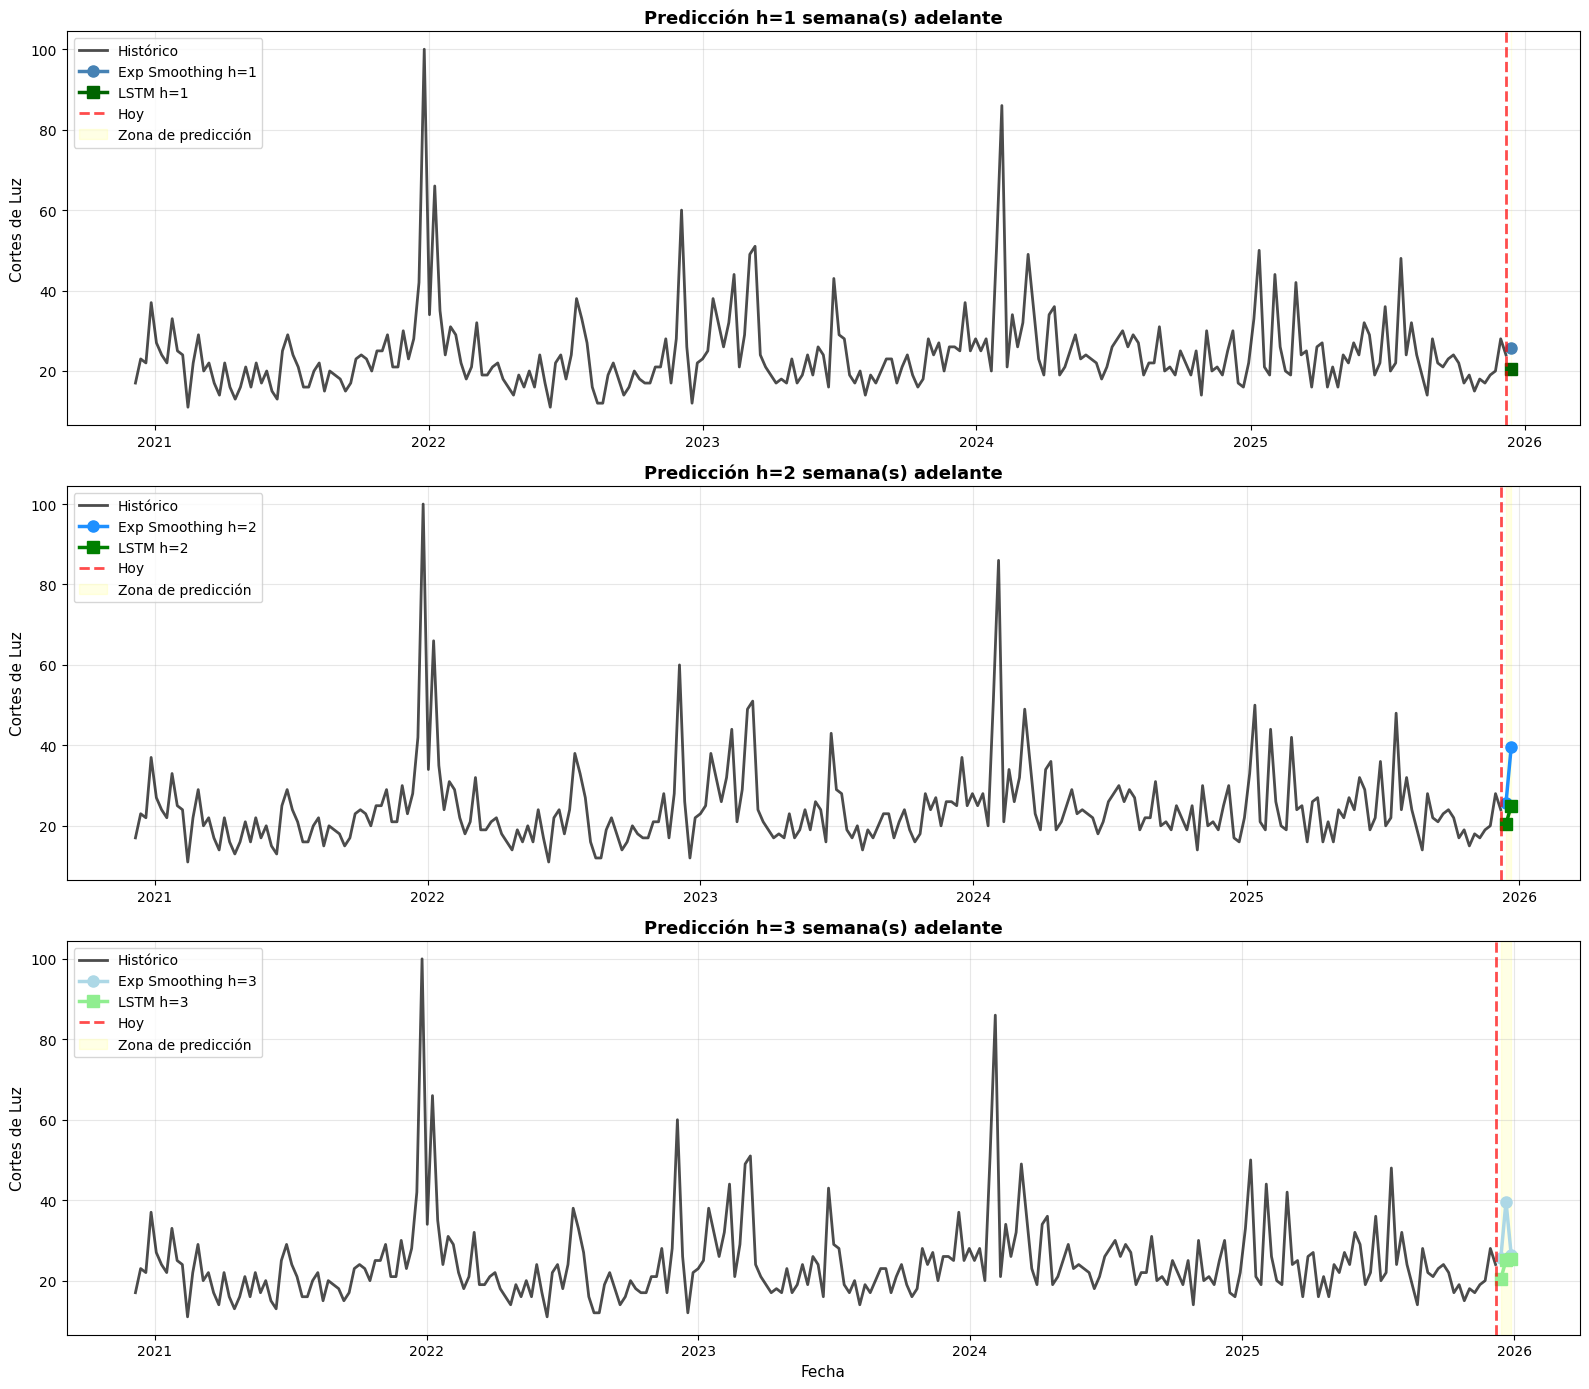

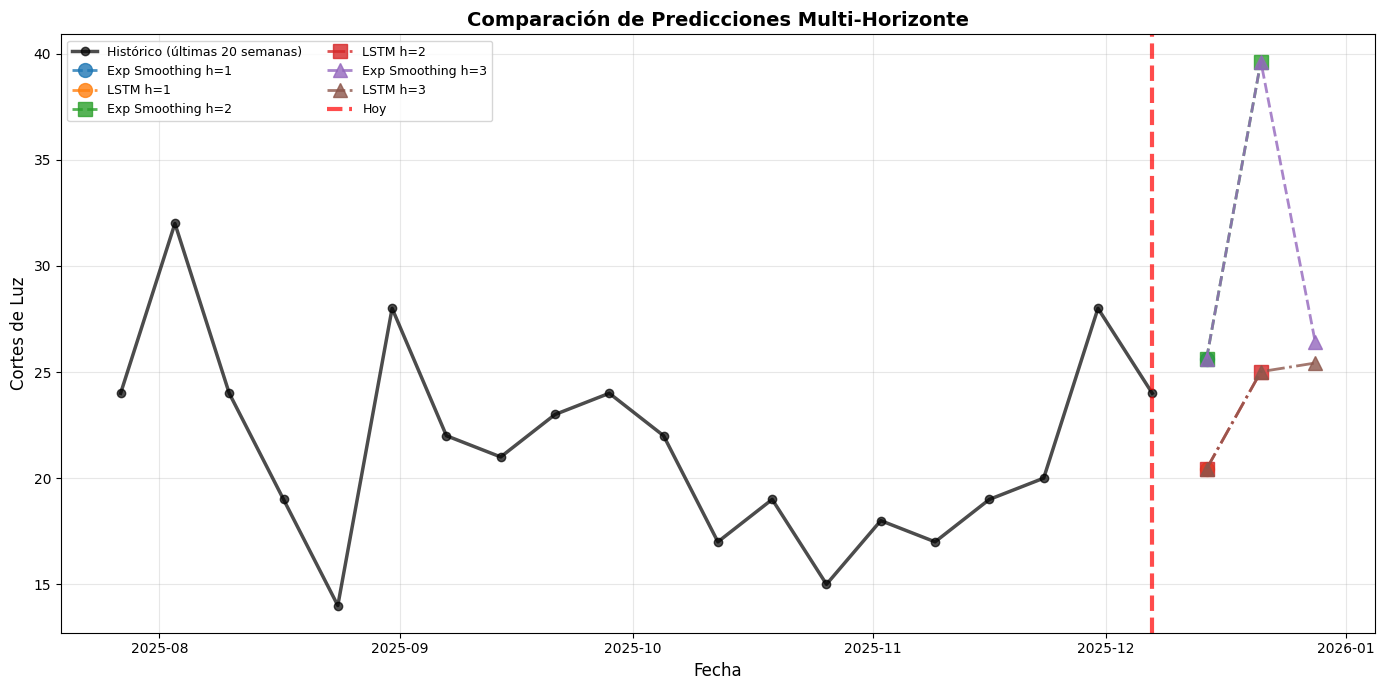

In [65]:
# VISUALIZACIÓN COMPLETA
# Gráfico 1: Serie completa + predicciones para cada horizonte
fig, axes = plt.subplots(3, 1, figsize=(16, 14))

colores_exp = ['steelblue', 'dodgerblue', 'lightblue']
colores_lstm = ['darkgreen', 'green', 'lightgreen']

for idx, h in enumerate(horizontes_futuro):
    ax = axes[idx]

    # Histórico
    ax.plot(serie_cortes.time_index, serie_cortes.values(),
            label='Histórico', linewidth=2, color='black', alpha=0.7)

    # Predicciones Exp Smoothing
    pred_exp = predicciones[f'Exp_Smoothing_h{h}']
    ax.plot(pred_exp.time_index, pred_exp.values(),
            'o-', label=f'Exp Smoothing h={h}',
            linewidth=2.5, markersize=8, color=colores_exp[idx])

    # Predicciones LSTM
    pred_lstm = predicciones[f'LSTM_h{h}']
    ax.plot(pred_lstm.time_index, pred_lstm.values(),
            's-', label=f'LSTM h={h}',
            linewidth=2.5, markersize=8, color=colores_lstm[idx])

    # Línea vertical "hoy"
    ax.axvline(x=serie_cortes.end_time(), color='red',
               linestyle='--', linewidth=2, alpha=0.7, label='Hoy')

    # Área de predicción
    ax.axvspan(pred_exp.start_time(), pred_exp.end_time(),
               alpha=0.1, color='yellow', label='Zona de predicción')

    ax.set_title(f'Predicción h={h} semana(s) adelante',
                 fontsize=13, fontweight='bold')
    ax.set_ylabel('Cortes de Luz', fontsize=11)
    ax.legend(loc='best', fontsize=10)
    ax.grid(alpha=0.3)

    if idx == 2:
        ax.set_xlabel('Fecha', fontsize=11)

plt.tight_layout()
plt.show()

# Gráfico 2: Comparación directa de predicciones
fig, ax = plt.subplots(1, 1, figsize=(14, 7))

# Últimas 20 semanas del histórico
ultimas_20 = serie_cortes[-20:]
ax.plot(ultimas_20.time_index, ultimas_20.values(),
        'o-', label='Histórico (últimas 20 semanas)',
        linewidth=2.5, markersize=6, color='black', alpha=0.7)

# Todas las predicciones
marcadores = ['o', 's', '^']
for idx, h in enumerate(horizontes_futuro):
    pred_exp = predicciones[f'Exp_Smoothing_h{h}']
    pred_lstm = predicciones[f'LSTM_h{h}']

    ax.plot(pred_exp.time_index, pred_exp.values(),
            marker=marcadores[idx], linestyle='--',
            label=f'Exp Smoothing h={h}',
            linewidth=2, markersize=10, alpha=0.8)

    ax.plot(pred_lstm.time_index, pred_lstm.values(),
            marker=marcadores[idx], linestyle='-.',
            label=f'LSTM h={h}',
            linewidth=2, markersize=10, alpha=0.8)

ax.axvline(x=serie_cortes.end_time(), color='red',
           linestyle='--', linewidth=3, alpha=0.7, label='Hoy')

ax.set_title('Comparación de Predicciones Multi-Horizonte',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Fecha', fontsize=12)
ax.set_ylabel('Cortes de Luz', fontsize=12)
ax.legend(loc='best', fontsize=9, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [66]:
# ANÁLISIS DE CONSENSO

for h in horizontes_futuro:
    pred_exp = predicciones[f'Exp_Smoothing_h{h}']
    pred_lstm = predicciones[f'LSTM_h{h}']

    valores_exp = pred_exp.values().flatten()
    valores_lstm = pred_lstm.values().flatten()

    diferencias = np.abs(valores_exp - valores_lstm)
    diff_promedio = np.mean(diferencias)
    diff_max = np.max(diferencias)

    print(f"h={h} semanas:")
    print(f"  Diferencia promedio: {diff_promedio:.1f} cortes")
    print(f"  Diferencia máxima:   {diff_max:.1f} cortes")

    # Nivel de consenso
    if diff_promedio < 3:
        consenso = "🟢 ALTO - Modelos concuerdan"
    elif diff_promedio < 5:
        consenso = "🟡 MEDIO - Discrepancia moderada"
    else:
        consenso = "🔴 BAJO - Modelos divergen significativamente"

    print(f"  Nivel de consenso: {consenso}\n")


h=1 semanas:
  Diferencia promedio: 5.2 cortes
  Diferencia máxima:   5.2 cortes
  Nivel de consenso: 🔴 BAJO - Modelos divergen significativamente

h=2 semanas:
  Diferencia promedio: 9.9 cortes
  Diferencia máxima:   14.6 cortes
  Nivel de consenso: 🔴 BAJO - Modelos divergen significativamente

h=3 semanas:
  Diferencia promedio: 6.9 cortes
  Diferencia máxima:   14.6 cortes
  Nivel de consenso: 🔴 BAJO - Modelos divergen significativamente



Las predicciones futuras revelan una **discrepancia significativa y sistemática** entre Exponential Smoothing y LSTM que genera incertidumbre considerable sobre la evolución del interés público en cortes eléctricos. Para la semana inmediata (h=1, 14-dic-2025), Exponential Smoothing predice un índice de búsquedas de 26 mientras LSTM anticipa solo 20, una diferencia de 5.2 puntos (23% de divergencia). Esta brecha se amplifica dramáticamente en h=2: para la semana del 21-dic-2025, Exp Smoothing proyecta un **pico de 40 búsquedas** mientras LSTM predice 25, una discrepancia de 14.6 puntos (37% de diferencia). Esta divergencia extrema es crítica porque ocurre precisamente en el horizonte donde ambos modelos habían demostrado mejor performance durante la validación (LSTM con MAPE 22.46% y Exp Smoothing 26.26% en h=2). El análisis de consenso confirma **nivel BAJO en todos los horizontes** (diferencias promedio 5.2-9.9 puntos), indicando que los modelos están capturando patrones fundamentalmente diferentes sobre el comportamiento de búsqueda del público.

La naturaleza de la discrepancia es particularmente reveladora: **Exponential Smoothing detecta un evento extremo inminente** (40 búsquedas en semana 2, seguido de retroceso a 26 en semana 3), sugiriendo un pico aislado de interés público que podría anticipar quejas masivas relacionadas con deterioro estacional del servicio eléctrico, condiciones climáticas adversas (tormentas de verano que causan cortes), o eventos puntuales de fallas en infraestructura crítica. En contraste, **LSTM predice estabilidad relativa** (20-25 búsquedas consistentes), reflejando su naturaleza de aprendizaje profundo que promedia patrones históricos complejos y suaviza fluctuaciones extremas. Esta divergencia no es error sino reflejo de las **filosofías predictivas contrastantes**: Exp Smoothing prioriza reactividad a tendencias recientes en el comportamiento de búsqueda (de ahí su 82.6% de captura de variabilidad), mientras LSTM busca patrones estructurales de largo plazo sacrificando sensibilidad a picos individuales de interés público (62.2% de variabilidad).

**Para traducir estas predicciones en acciones operativas concretas**, resulta fundamental establecer **umbrales de severidad calibrados** que relacionen el volumen de búsquedas en Google Trends con la magnitud real de interrupciones eléctricas experimentadas por los usuarios. El análisis histórico de la serie sugiere que el promedio de 23-25 búsquedas representa condiciones normales de servicio con cortes localizados y breves. Proponemos un **sistema de umbrales escalonados**. Bajo este marco de umbrales, las predicciones podrían adquirir significado operativo claro.